# Library


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings
warnings.filterwarnings('ignore')


# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Path to data
data_path = r"D:\Polythecninco di Milano\AFB_Lab\Data\Camihawke\\"
print("Data path:", data_path)

Data path: D:\Polythecninco di Milano\AFB_Lab\Data\Camihawke\\


In [3]:
# Remove pandas display limits for DataFrame columns
pd.set_option("display.max_columns", None)


# Functions

In [5]:
def memory_report():
    # Memory allocation report for notebook objects (DataFrames + NumPy arrays)
    memory_report = []

    global_items = list(globals().items())  # freeze snapshot to avoid RuntimeError
    for name, obj in global_items:
        if isinstance(obj, pd.DataFrame):
            mem_mb = obj.memory_usage(deep=True).sum() / (1024 ** 2)
            memory_report.append((name, "DataFrame", str(obj.shape), mem_mb))
        elif isinstance(obj, np.ndarray):
            mem_mb = obj.nbytes / (1024 ** 2)
            memory_report.append((name, "ndarray", str(obj.shape), mem_mb))

    memory_df = pd.DataFrame(memory_report, columns=["variable", "type", "shape", "memory_mb"])
    memory_df = memory_df.sort_values("memory_mb", ascending=False).reset_index(drop=True)

    print("=== MEMORY ALLOCATION REPORT ===")
    print(memory_df.to_string(index=False))
    print(f"\nTotal memory (reported objects): {memory_df['memory_mb'].sum():.2f} MB")

    # Optional: detailed per-column memory for main datasets
    print("\n=== fb_posts column-wise memory (MB) ===")
    print((fb_posts.memory_usage(deep=True) / (1024 ** 2)).sort_values(ascending=False))

    print("\n=== tk_posts column-wise memory (MB) ===")
    print((tk_posts.memory_usage(deep=True) / (1024 ** 2)).sort_values(ascending=False))

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import ks_2samp

def missingness_and_bias_report(df_before, df_after=None, title="Dataset", bias_threshold_pct=10, ks_alpha=0.05):
    import matplotlib.pyplot as plt

    try:
        from scipy.stats import ks_2samp as _ks_2samp
        ks_test_fn = _ks_2samp
    except Exception:
        ks_test_fn = None

    # -----------------------
    # Missingness report
    # -----------------------
    missing_pct = df_before.isnull().mean().mul(100).sort_values(ascending=False)
    missing_table = pd.DataFrame({
        "feature": missing_pct.index,
        "missing_pct": missing_pct.values,
        "missing_count": df_before.isnull().sum().loc[missing_pct.index].values
    })

    overall_missing_pct = (df_before.isnull().sum().sum() / df_before.size * 100) if df_before.size else 0

    print(f"\n=== {title} : MISSINGNESS REPORT ===")
    print(f"Dataset shape: {df_before.shape}")
    print(f"Overall missingness: {overall_missing_pct:.2f}% of all cells\n")
    print(missing_table.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    sns.heatmap(df_before.isnull(), cbar=False, yticklabels=False, cmap="viridis", ax=axes[0])
    axes[0].set_title(f"{title} - Missing Values Heatmap", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Columns")
    axes[0].set_ylabel("Rows")

    sns.barplot(
        data=missing_table,
        x="missing_pct",
        y="feature",
        ax=axes[1],
        color="steelblue"
    )
    axes[1].set_title(f"{title} - Missingness by Feature (%)", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Missing %")
    axes[1].set_ylabel("")
    plt.tight_layout()
    plt.show()

    # -----------------------
    # Distribution shift / bias checks
    # Compare raw vs cleaned/prepared before scaling if possible
    # -----------------------
    if df_after is not None:
        print(f"\n=== {title} : DISTRIBUTION SHIFT CHECK ===")

        common_cols = [c for c in df_before.columns if c in df_after.columns]
        numeric_cols = [
            c for c in common_cols
            if pd.api.types.is_numeric_dtype(df_before[c]) and pd.api.types.is_numeric_dtype(df_after[c])
        ]

        checks = []
        for col in numeric_cols:
            b = pd.to_numeric(df_before[col], errors="coerce").dropna()
            a = pd.to_numeric(df_after[col], errors="coerce").dropna()

            if len(b) < 2 or len(a) < 2:
                continue

            mean_before = b.mean()
            mean_after = a.mean()
            std_before = b.std()
            std_after = a.std()

            mean_change_pct = np.nan if mean_before == 0 else abs(mean_after - mean_before) / abs(mean_before) * 100
            ks_stat = np.nan
            ks_pvalue = np.nan
            if ks_test_fn is not None:
                try:
                    ks_stat, ks_pvalue = ks_test_fn(b, a)
                except Exception:
                    pass
                except Exception:
                    pass

            std_change_pct = np.nan if std_before == 0 else abs(std_after - std_before) / abs(std_before) * 100

            checks.append({
                "feature": col,
                "mean_before": mean_before,
                "mean_after": mean_after,
                "mean_abs_pct_change": mean_change_pct,
                "std_abs_pct_change": std_change_pct,
                "ks_stat": ks_stat,
                "ks_pvalue": ks_pvalue
            })

        if checks:
            checks_df = pd.DataFrame(checks).sort_values(
                by=["ks_pvalue", "mean_abs_pct_change"],
                ascending=[True, False],
                na_position="last"
            )

            print(checks_df.to_string(index=False))

            flags = checks_df[
                ((checks_df["mean_abs_pct_change"] > bias_threshold_pct) |
                 (checks_df["std_abs_pct_change"] > bias_threshold_pct) |
                 (checks_df["ks_pvalue"].notna() & (checks_df["ks_pvalue"] < ks_alpha)))
            ]

            if len(flags) > 0:
                print("\nPotential distribution shifts detected:")
                print(flags[["feature", "mean_abs_pct_change", "std_abs_pct_change", "ks_pvalue"]].to_string(index=False))
            else:
                print("\nNo strong distribution shifts detected under the current thresholds.")
        else:
            print("No numeric common columns available for distribution comparison.")

    return missing_table

# Load Data


In [5]:
# Load Facebook data
fb_posts = pd.read_csv(f"{data_path}fb_posts.csv")
fb_comments = pd.read_csv(f"{data_path}fb_comments.csv")

print("Facebook Posts shape:", fb_posts.shape)
print("Facebook Comments shape:", fb_comments.shape)
print("\nFacebook Posts columns:", fb_posts.columns.tolist())
print("\nFacebook Comments columns:", fb_comments.columns.tolist())

Facebook Posts shape: (390, 21)
Facebook Comments shape: (394084, 9)

Facebook Posts columns: ['post_id', 'message', 'created_time', 'permalink_url', 'shares_count', 'comments_count', 'reactions_count', 'reactions_like', 'reactions_love', 'reactions_wow', 'reactions_haha', 'reactions_sorry', 'reactions_anger', 'reach', 'impressions', 'clicks', 'clicks_by_type', 'engaged_users', 'video_views', 'video_view_time', 'comments_downloaded']

Facebook Comments columns: ['comment_id', 'post_id', 'message', 'like_count', 'created_time', 'from_name', 'from_id', 'parent_id', 'comment_count']


In [6]:
# Load TikTok data
tk_posts = pd.read_csv(f"{data_path}tk_posts.csv")
tk_comments = pd.read_csv(f"{data_path}tk_comments.csv")

print("TikTok Posts shape:", tk_posts.shape)
print("TikTok Comments shape:", tk_comments.shape)
print("\nTikTok Posts columns:", tk_posts.columns.tolist())
print("\nTikTok Comments columns:", tk_comments.columns.tolist())

TikTok Posts shape: (335, 9)
TikTok Comments shape: (19654, 13)

TikTok Posts columns: ['media_id', 'creation_date', 'create_time', 'caption', 'comments_count', 'like_count', 'views', 'shares', 'comments_downloaded']

TikTok Comments columns: ['cid', 'media_id', 'text', 'create_time', 'digg_count', 'nickname', 'uid', 'comment_language', 'reply_comment_total', 'reply_id', 'reply_to_reply_id', 'is_author_digged', 'author_pin']


# 1. Data Cleaning Facebook Posts

In [7]:
print("=== FACEBOOK POSTS ===")
print(f"Shape: {fb_posts.shape}")
print(f"\nFirst few rows:")
print(fb_posts.head())
print(f"\nData types:\n{fb_posts.dtypes}")
print(f"\nMissing values:\n{fb_posts.isnull().sum()}")
print(f"\nBasic statistics:\n{fb_posts.describe()}")

=== FACEBOOK POSTS ===
Shape: (390, 21)

First few rows:
                             post_id  \
0  1686085491707042_1460530322105908   
1  1686085491707042_1447128706779403   
2  1686085491707042_1445563560269251   
3  1686085491707042_1442825210543086   
4  1686085491707042_1456809062478034   

                                             message  \
0       Quando si sbaglia è importante riconoscerlo.   
1  #adv Non so se sul lungo mare di Sanremo abbia...   
2  #adv Oggi ho giocato a gira la moda in real li...   
3  Alla domanda se mi hanno fatto mai pesare di n...   
4  Sul canale YouTube è uscita una nuova game nig...   

               created_time                                    permalink_url  \
0  2026-03-17T12:45:11+0000  https://www.facebook.com/reel/1607929663795233/   
1  2026-02-27T16:00:13+0000  https://www.facebook.com/reel/1190230669855920/   
2  2026-02-25T19:33:14+0000  https://www.facebook.com/reel/2078820786236877/   
3  2026-02-22T10:58:39+0000  https://www.face


=== Dataset : MISSINGNESS REPORT ===
Dataset shape: (390, 21)
Overall missingness: 21.72% of all cells

            feature  missing_pct  missing_count
      engaged_users   100.000000            390
        impressions   100.000000            390
    reactions_anger    58.461538            228
    video_view_time    55.641026            217
    reactions_sorry    48.717949            190
     clicks_by_type    37.435897            146
      reactions_wow    18.205128             71
     reactions_haha    12.307692             48
       shares_count    11.282051             44
     reactions_love     6.923077             27
     reactions_like     6.153846             24
            message     1.025641              4
            post_id     0.000000              0
      permalink_url     0.000000              0
       created_time     0.000000              0
    reactions_count     0.000000              0
     comments_count     0.000000              0
             clicks     0.00000

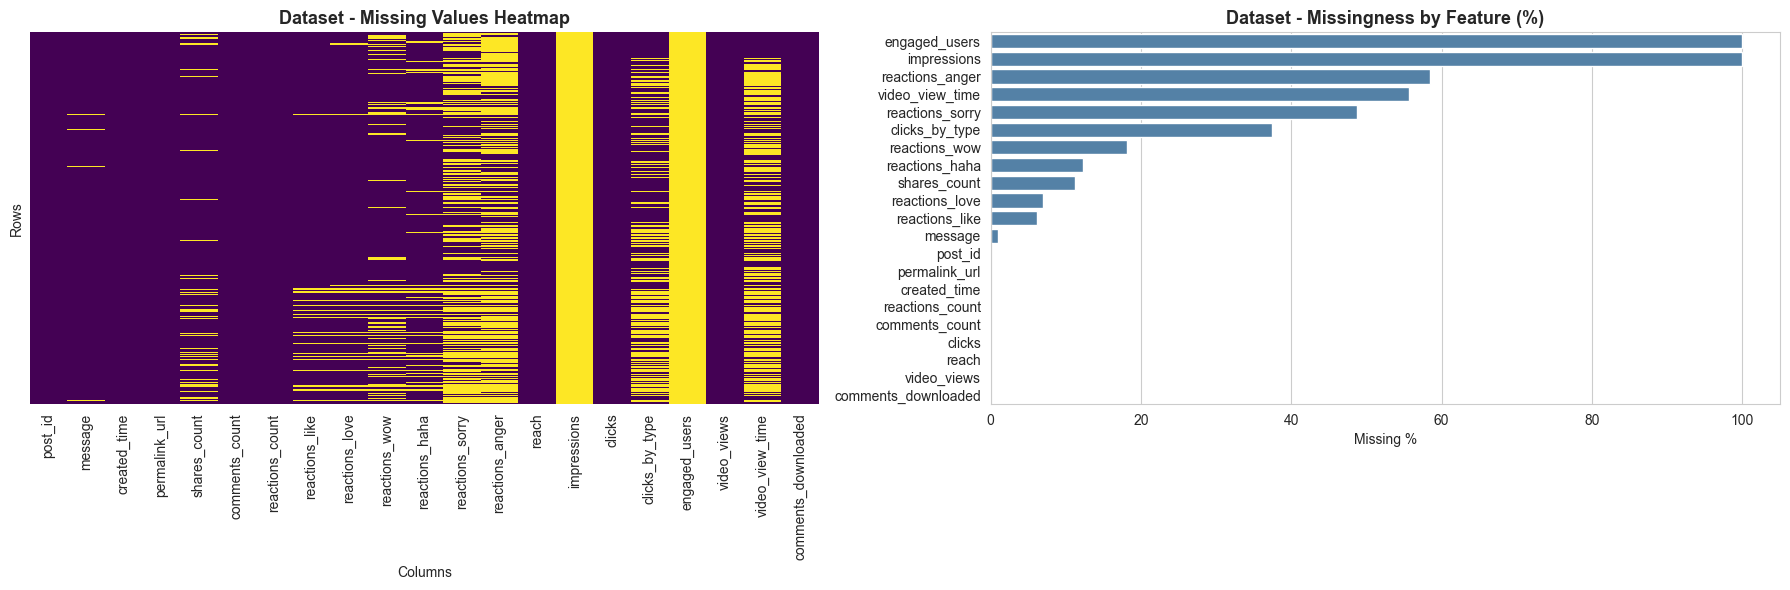

,feature,missing_pct,missing_count
0,engaged_users,100.000000,390
1,impressions,100.000000,390
2,reactions_anger,58.461538,228
3,video_view_time,55.641026,217
4,reactions_sorry,48.717949,190
5,clicks_by_type,37.435897,146
6,reactions_wow,18.205128,71
7,reactions_haha,12.307692,48
8,shares_count,11.282051,44
9,reactions_love,6.923077,27


In [8]:
missingness_and_bias_report(fb_posts)

In [9]:
cols_to_drop = ["impressions", "engaged_users"]
fb_posts_clean = fb_posts.drop(columns=cols_to_drop)

print("Dropped columns:", cols_to_drop)
print("New shape:", fb_posts_clean.shape)

Dropped columns: ['impressions', 'engaged_users']
New shape: (390, 19)


In [10]:
fb_posts_clean.post_id.nunique()

390

In [11]:
fb_posts_clean["message"] = fb_posts_clean["message"].fillna("no_message")

print("Remaining NaN in fb_posts_clean['message']:", fb_posts_clean["message"].isna().sum())

Remaining NaN in fb_posts_clean['message']: 0


In [12]:
import json

def _parse_clicks_by_type(row):
    value = row["clicks_by_type"]
    total_clicks = row["clicks"] if pd.notna(row["clicks"]) else 0

    if pd.isna(value):
        return {"other clicks": total_clicks}

    if isinstance(value, dict):
        return value

    try:
        parsed = json.loads(value)
        return parsed if isinstance(parsed, dict) else {"other clicks": total_clicks}
    except Exception:
        return {"other clicks": total_clicks}

click_dicts = fb_posts_clean.apply(_parse_clicks_by_type, axis=1)

clicks_expanded = pd.json_normalize(click_dicts).fillna(0)

clicks_expanded.columns = (
    clicks_expanded.columns
    .str.lower()
    .str.replace(r"[^0-9a-zA-Z]+", "_", regex=True)
    .str.strip("_")
    .map(lambda c: f"clicks_{c}")
)

fb_posts_clean = pd.concat([fb_posts_clean, clicks_expanded], axis=1)

print("Added click columns:", clicks_expanded.columns.tolist())

Added click columns: ['clicks_other_clicks', 'clicks_link_clicks', 'clicks_photo_view', 'clicks_video_play']


In [13]:
fb_posts_clean = fb_posts_clean.drop(columns=["clicks_by_type"])

In [14]:
has_zero_shares = (fb_posts_clean["shares_count"] == 0).any()
print("Zero present in shares_count:", has_zero_shares)

Zero present in shares_count: False


In [15]:
fb_posts_clean["shares_count"] = fb_posts_clean["shares_count"].fillna(0)

In [16]:
fb_posts_clean.shape

(390, 22)

Reaction type columns used: ['reactions_like', 'reactions_love', 'reactions_wow', 'reactions_haha', 'reactions_sorry', 'reactions_anger']

Diff summary (reactions_count - reactions_sum_by_type):
count       390.000000
mean      -2369.335897
std        9642.262851
min     -113206.000000
25%        -670.000000
50%           0.000000
75%           0.000000
max        7110.000000
Name: reactions_diff, dtype: float64

Rows with non-zero diff: 205
Top diff values:
reactions_diff
 0.0      185
-220.0      2
-104.0      2
-47.0       2
 1.0        2
 397.0      2
-22.0       1
-198.0      1
-35.0       1
-68.0       1
Name: count, dtype: int64


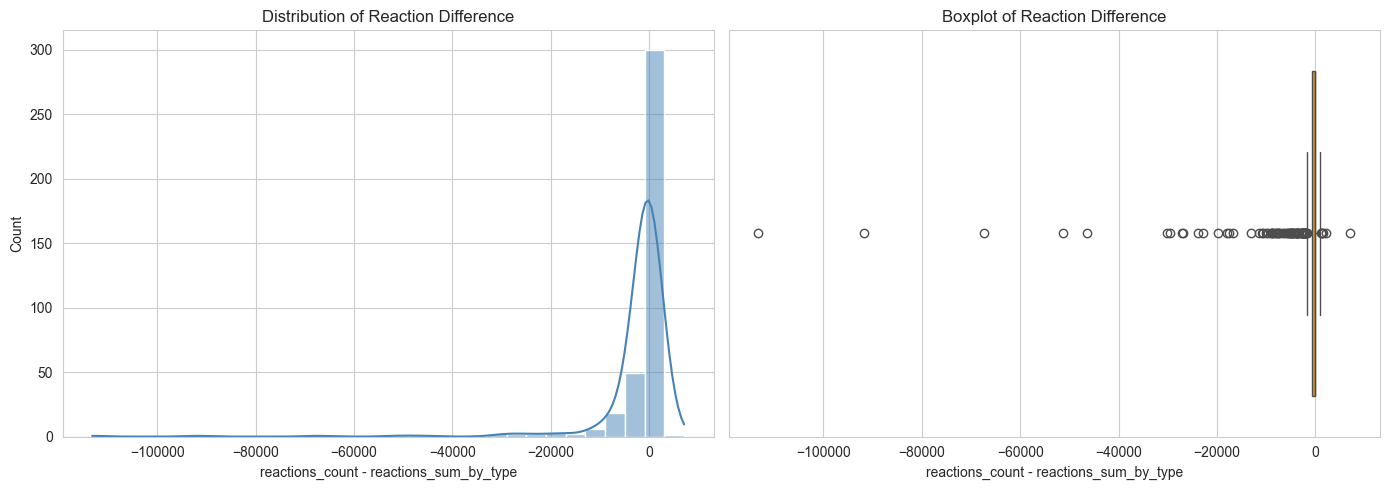

In [17]:
# Sum reactions by type and compare against reactions_count
reaction_type_cols = [
    c for c in fb_posts_clean.columns
    if c.startswith("reactions_") and c not in ["reactions_count", "reactions_count_calc"]
]

fb_posts_clean["reactions_sum_by_type"] = fb_posts_clean[reaction_type_cols].fillna(0).sum(axis=1)
fb_posts_clean["reactions_diff"] = fb_posts_clean["reactions_count"] - fb_posts_clean["reactions_sum_by_type"]

print("Reaction type columns used:", reaction_type_cols)
print("\nDiff summary (reactions_count - reactions_sum_by_type):")
print(fb_posts_clean["reactions_diff"].describe())

print("\nRows with non-zero diff:", (fb_posts_clean["reactions_diff"] != 0).sum())
print("Top diff values:")
print(fb_posts_clean["reactions_diff"].value_counts().head(10))

# Distribution of diff
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(fb_posts_clean["reactions_diff"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Reaction Difference")
axes[0].set_xlabel("reactions_count - reactions_sum_by_type")

sns.boxplot(x=fb_posts_clean["reactions_diff"], ax=axes[1], color="orange")
axes[1].set_title("Boxplot of Reaction Difference")
axes[1].set_xlabel("reactions_count - reactions_sum_by_type")

plt.tight_layout()
plt.show()

Negative reactions_diff rows: 173
Zero reactions_diff rows: 185


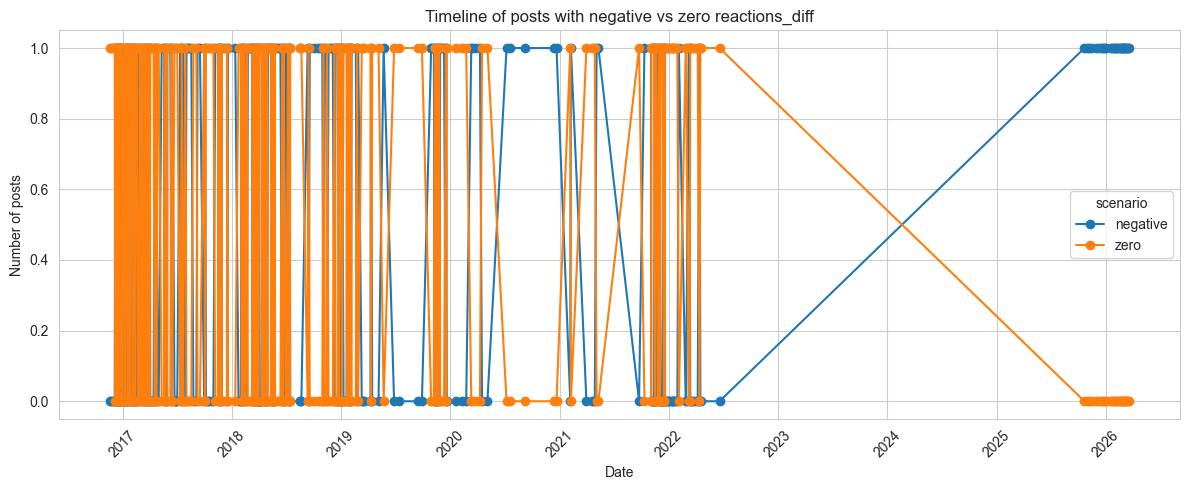

In [18]:
# Timeline + rows for reactions_diff negative and zero
df_timeline = fb_posts_clean.copy()
df_timeline["created_time_dt"] = pd.to_datetime(df_timeline["created_time"], errors="coerce", utc=True)

neg_rows = df_timeline[df_timeline["reactions_diff"] < 0].copy()
zero_rows = df_timeline[df_timeline["reactions_diff"] == 0].copy()

print(f"Negative reactions_diff rows: {len(neg_rows)}")
print(f"Zero reactions_diff rows: {len(zero_rows)}")

# Show rows for both scenarios
cols_show = [
    "post_id", "created_time", "reactions_count",
    "reactions_sum_by_type", "reactions_diff", "message"
]


# Build daily timeline
timeline_df = pd.concat([
    neg_rows.assign(scenario="negative"),
    zero_rows.assign(scenario="zero")
], axis=0)

timeline_counts = (
    timeline_df
    .dropna(subset=["created_time_dt"])
    .assign(day=lambda x: x["created_time_dt"].dt.date)
    .groupby(["day", "scenario"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Plot timeline
ax = timeline_counts.plot(marker="o", figsize=(12, 5))
ax.set_title("Timeline of posts with negative vs zero reactions_diff")
ax.set_xlabel("Date")
ax.set_ylabel("Number of posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== Correlation with reactions_diff (sorted by absolute value) ===
clicks_other_clicks     -0.922928
shares_count            -0.915631
clicks                  -0.903961
reactions_sum_by_type   -0.886938
video_views             -0.885106
reach                   -0.871969
video_view_time         -0.866358
comments_count          -0.841321
reactions_like          -0.822723
clicks_video_play       -0.795215
reactions_haha          -0.757781
reactions_anger         -0.744586
reactions_love          -0.732575
reactions_count         -0.725381
clicks_link_clicks      -0.666253
reactions_sorry         -0.457907
reactions_wow           -0.417320
clicks_photo_view        0.056993
comments_downloaded           NaN


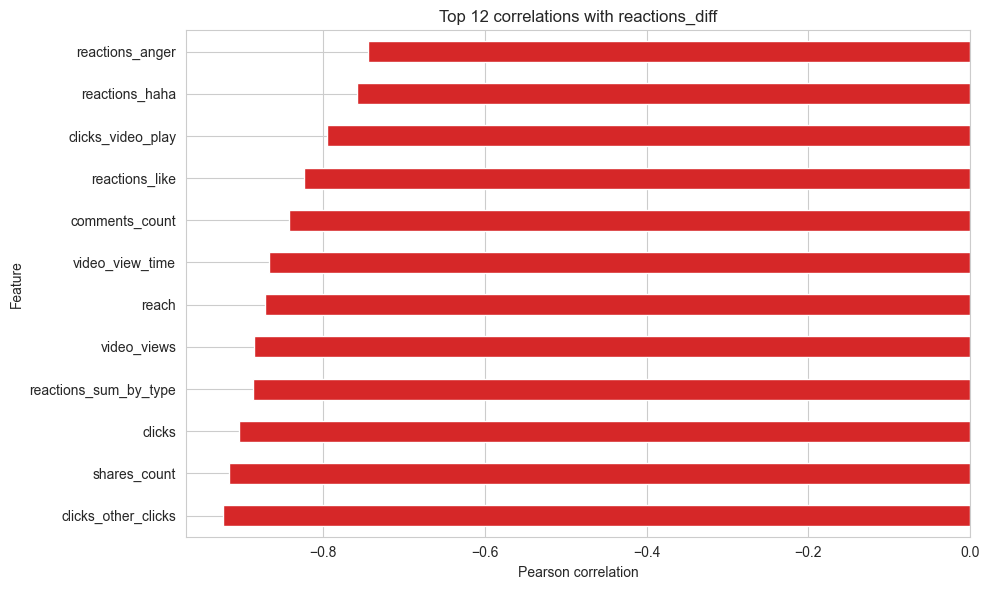


Pairplot columns: ['reactions_diff', 'clicks_other_clicks', 'shares_count', 'clicks', 'reactions_sum_by_type', 'video_views']
Rows available after dropna: 390


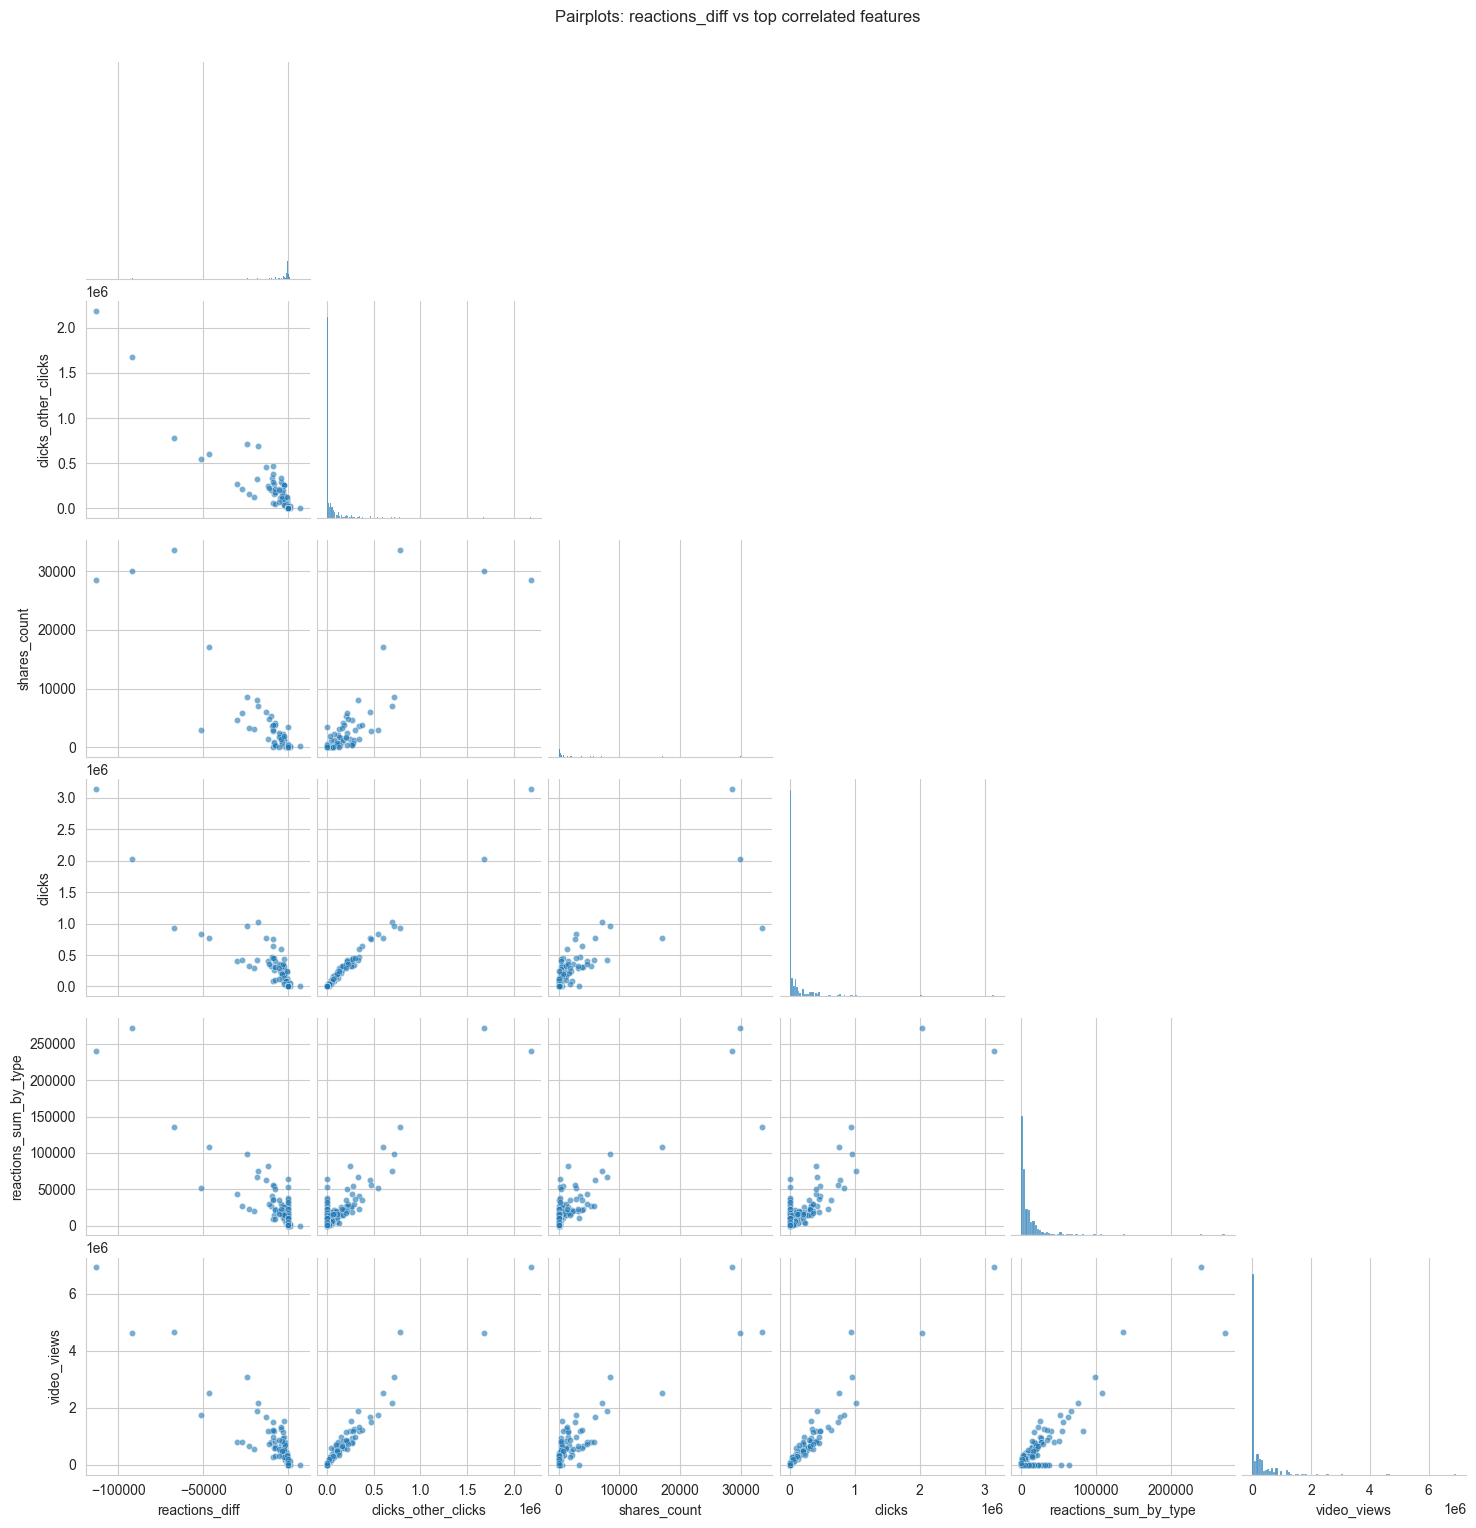

In [19]:
# Correlation check: reactions_diff vs other numeric features
num_df = fb_posts_clean.select_dtypes(include=[np.number]).copy()

if "reactions_diff" not in num_df.columns:
    raise ValueError("'reactions_diff' not found in fb_posts_clean. Run the diff computation cell first.")

corr_with_diff = (
    num_df.corr(numeric_only=True)["reactions_diff"]
    .drop("reactions_diff")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("=== Correlation with reactions_diff (sorted by absolute value) ===")
print(corr_with_diff.to_string())

# Visualize top correlations
top_n = 12
top_corr = corr_with_diff.head(top_n).sort_values()

plt.figure(figsize=(10, 6))
top_corr.plot(kind="barh", color=["#d62728" if v < 0 else "#1f77b4" for v in top_corr.values])
plt.title(f"Top {top_n} correlations with reactions_diff")
plt.xlabel("Pearson correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Pairplots for reactions_diff + strongest correlated features
exclude_for_pairplot = {"reactions_count_calc"}  # optional: remove derived/duplicate fields
pair_features = [c for c in corr_with_diff.index if c not in exclude_for_pairplot][:5]
pairplot_cols = ["reactions_diff"] + pair_features

pair_df = (
    fb_posts_clean[pairplot_cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

print(f"\nPairplot columns: {pairplot_cols}")
print(f"Rows available after dropna: {len(pair_df)}")

if len(pair_df) >= 5:
    sns.pairplot(
        pair_df.sample(min(300, len(pair_df)), random_state=42),
        diag_kind="hist",
        corner=True,
        plot_kws={"alpha": 0.6, "s": 20}
    )
    plt.suptitle("Pairplots: reactions_diff vs top correlated features", y=1.02)
    plt.show()
else:
    print("Not enough complete rows to generate pairplots.")


=== Correlation with reaction_types_sum ===
reactions_sum_by_type    1.000000
reactions_like           0.965565
reactions_count          0.961308
video_view_time          0.941082
clicks_other_clicks      0.924025
video_views              0.901304
clicks                   0.895272
reactions_diff          -0.886938
shares_count             0.877498
reach                    0.854092
comments_count           0.842851
reactions_love           0.828471
reactions_anger          0.811163
clicks_video_play        0.765268
reactions_haha           0.727086
clicks_link_clicks       0.596875
reactions_sorry          0.584405
reactions_wow            0.536734
clicks_photo_view        0.061416
comments_downloaded           NaN


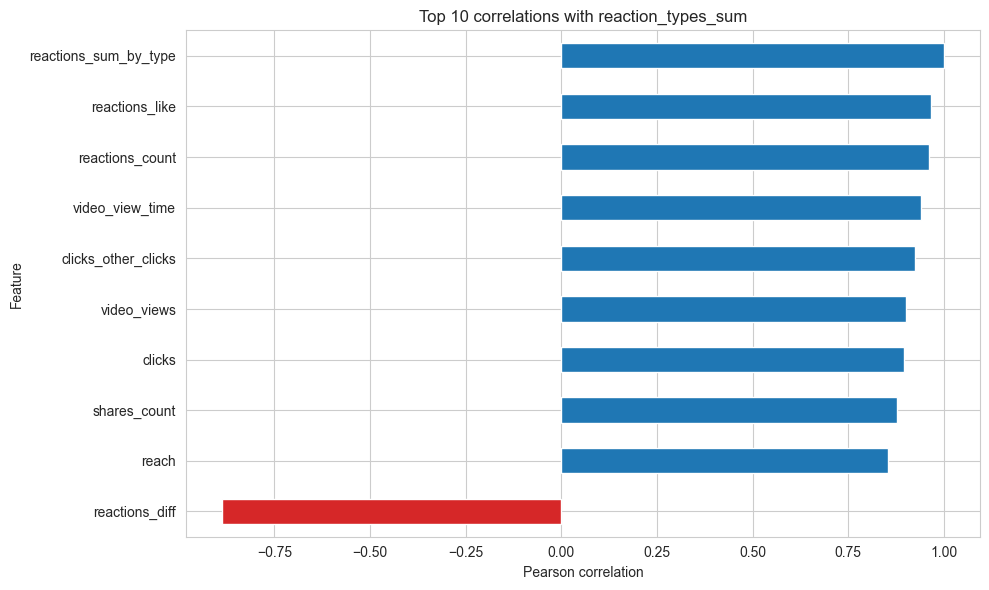


=== Correlation with reactions_count ===
reactions_sum_by_type    0.961308
reaction_types_sum       0.961308
reactions_like           0.948150
video_view_time          0.901233
clicks_other_clicks      0.826619
video_views              0.815314
reactions_love           0.797538
clicks                   0.795080
reactions_anger          0.765547
shares_count             0.761632
comments_count           0.754317
reach                    0.752790
reactions_diff          -0.725381
clicks_video_play        0.666194
reactions_haha           0.631009
reactions_sorry          0.597018
reactions_wow            0.552095
clicks_link_clicks       0.492154
clicks_photo_view        0.125519
comments_downloaded           NaN


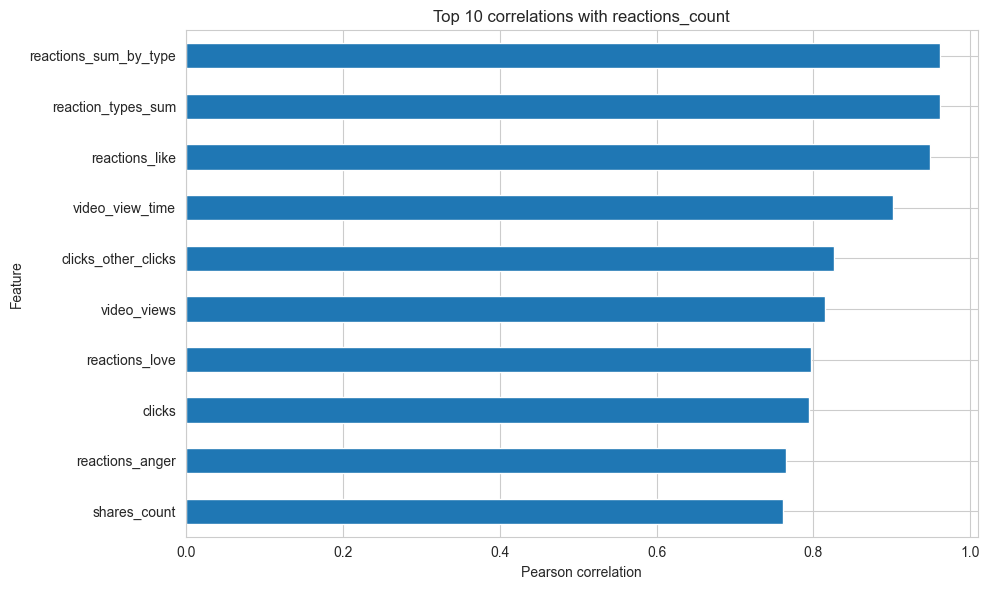


=== Correlation between reaction_types_sum and reactions_count ===
0.9613079973515661


In [20]:
# Correlation check: sum of reaction types vs other features, then reactions_count vs other features

reaction_type_sum_col = "reaction_types_sum"

if "reaction_type_cols" in globals():
    reaction_type_cols_local = reaction_type_cols
elif "reaction_cols" in globals():
    reaction_type_cols_local = reaction_cols
else:
    reaction_type_cols_local = [c for c in fb_posts_clean.columns if c.startswith("reactions_") and c not in ["reactions_count", "reactions_count_calc"]]

corr_df = fb_posts_clean.copy()
corr_df[reaction_type_sum_col] = corr_df[reaction_type_cols_local].fillna(0).sum(axis=1)

numeric_cols = corr_df.select_dtypes(include=[np.number]).columns.tolist()

targets = [reaction_type_sum_col, "reactions_count"]

for target in targets:
    corr_series = (
        corr_df[numeric_cols]
        .corr(numeric_only=True)[target]
        .drop(labels=[target], errors="ignore")
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )

    print(f"\n=== Correlation with {target} ===")
    print(corr_series.to_string())

    top_n = 10
    top_corr = corr_series.head(top_n).sort_values()

    plt.figure(figsize=(10, 6))
    top_corr.plot(kind="barh", color=["#d62728" if v < 0 else "#1f77b4" for v in top_corr.values])
    plt.title(f"Top {top_n} correlations with {target}")
    plt.xlabel("Pearson correlation")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# Optional: direct comparison between the two targets
print("\n=== Correlation between reaction_types_sum and reactions_count ===")
print(corr_df[[reaction_type_sum_col, "reactions_count"]].corr().iloc[0, 1])

In [21]:
# Fill NaN with 0 for reaction-type columns, then drop reactions_count
if "reaction_type_cols" in globals():
    reaction_cols_to_fill = [c for c in reaction_type_cols if c in fb_posts_clean.columns]
else:
    reaction_cols_to_fill = [
        c for c in fb_posts_clean.columns
        if c.startswith("reactions_") and c != "reactions_count"
    ]

fb_posts_clean[reaction_cols_to_fill] = fb_posts_clean[reaction_cols_to_fill].fillna(0)
fb_posts_clean.drop(columns=["reactions_count"], inplace=True, errors="ignore")

print("Filled NaN with 0 in:", reaction_cols_to_fill)
print("'reactions_count' in columns:", "reactions_count" in fb_posts_clean.columns)
print("Remaining NaN in reaction-type columns:", fb_posts_clean[reaction_cols_to_fill].isna().sum().sum())

Filled NaN with 0 in: ['reactions_like', 'reactions_love', 'reactions_wow', 'reactions_haha', 'reactions_sorry', 'reactions_anger']
'reactions_count' in columns: False
Remaining NaN in reaction-type columns: 0


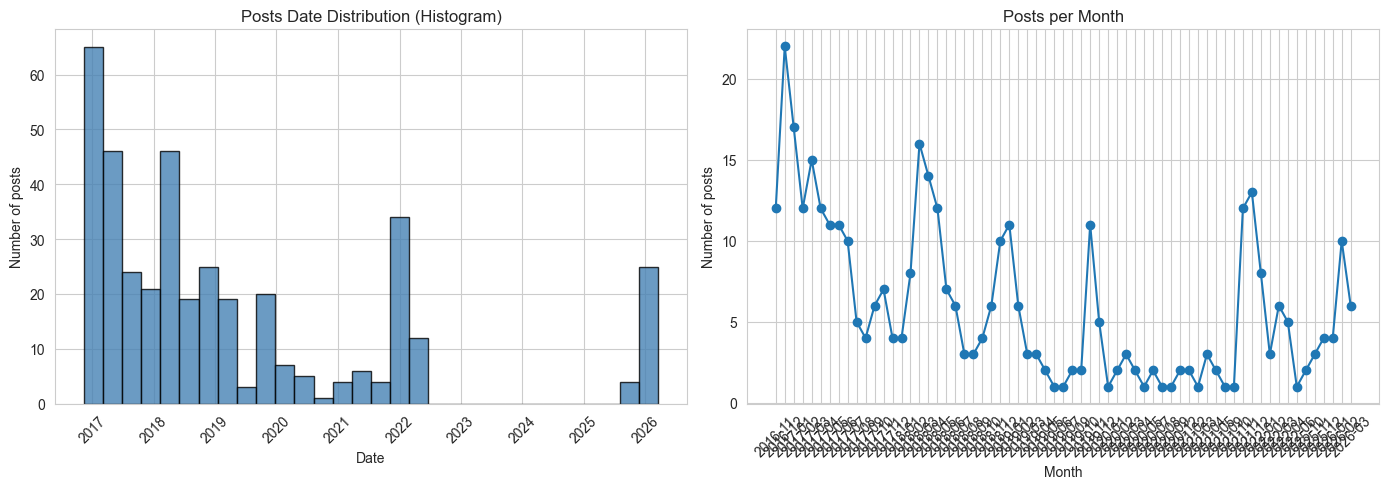

In [22]:
# Distribution of Facebook post dates
post_dates = pd.to_datetime(fb_posts_clean["created_time"], errors="coerce", utc=True).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Histogram over time
axes[0].hist(post_dates.dt.to_pydatetime(), bins=30, color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Posts Date Distribution (Histogram)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Number of posts")
axes[0].tick_params(axis="x", rotation=45)

# 2) Monthly counts timeline
monthly_counts = post_dates.dt.to_period("M").value_counts().sort_index()
axes[1].plot(monthly_counts.index.astype(str), monthly_counts.values, marker="o", linewidth=1.5)
axes[1].set_title("Posts per Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Number of posts")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [23]:
reaction_na_cols = [
    c for c in fb_posts_clean.columns
    if c.startswith("reactions_") and c not in ["reactions_count", "reactions_count_calc"]
]

fb_posts_clean[reaction_na_cols] = fb_posts_clean[reaction_na_cols].fillna(-99)

print("Updated columns:", reaction_na_cols)
print("Remaining NaN in reaction columns:", fb_posts_clean[reaction_na_cols].isna().sum().sum())

Updated columns: ['reactions_like', 'reactions_love', 'reactions_wow', 'reactions_haha', 'reactions_sorry', 'reactions_anger', 'reactions_sum_by_type', 'reactions_diff']
Remaining NaN in reaction columns: 0


In [24]:
fb_posts_clean["video_view_time"].sample(10)/60

187    1.262942e+08
272    6.414361e+08
104    2.542592e+08
378             NaN
101    2.332640e+09
277             NaN
64              NaN
8      2.346517e+07
285    3.510083e+08
129    3.528072e+09
Name: video_view_time, dtype: float64

<Axes: xlabel='video_view_time', ylabel='Count'>

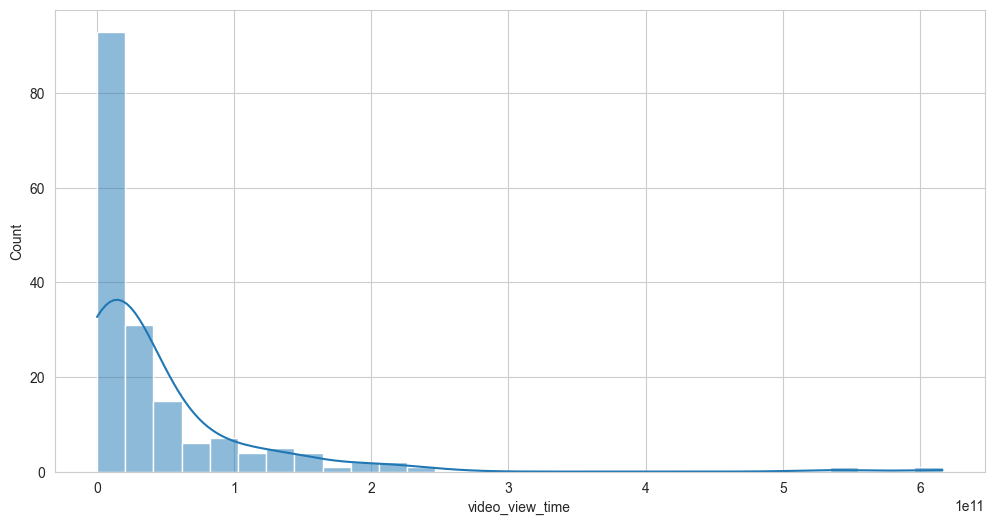

In [25]:
sns.histplot(fb_posts_clean["video_view_time"], bins=30, kde=True)

In [26]:
video_view_time_median = fb_posts_clean["video_view_time"].median()
fb_posts_clean["video_view_time"] = fb_posts_clean["video_view_time"].fillna(video_view_time_median)

print("Median used:", video_view_time_median)
print("Remaining NaN in video_view_time:", fb_posts_clean["video_view_time"].isna().sum())

Median used: 17010537203.0
Remaining NaN in video_view_time: 0



=== Dataset : MISSINGNESS REPORT ===
Dataset shape: (390, 23)
Overall missingness: 0.00% of all cells

              feature  missing_pct  missing_count
              post_id          0.0              0
              message          0.0              0
         created_time          0.0              0
        permalink_url          0.0              0
         shares_count          0.0              0
       comments_count          0.0              0
       reactions_like          0.0              0
       reactions_love          0.0              0
        reactions_wow          0.0              0
       reactions_haha          0.0              0
      reactions_sorry          0.0              0
      reactions_anger          0.0              0
                reach          0.0              0
               clicks          0.0              0
          video_views          0.0              0
      video_view_time          0.0              0
  comments_downloaded          0.0            

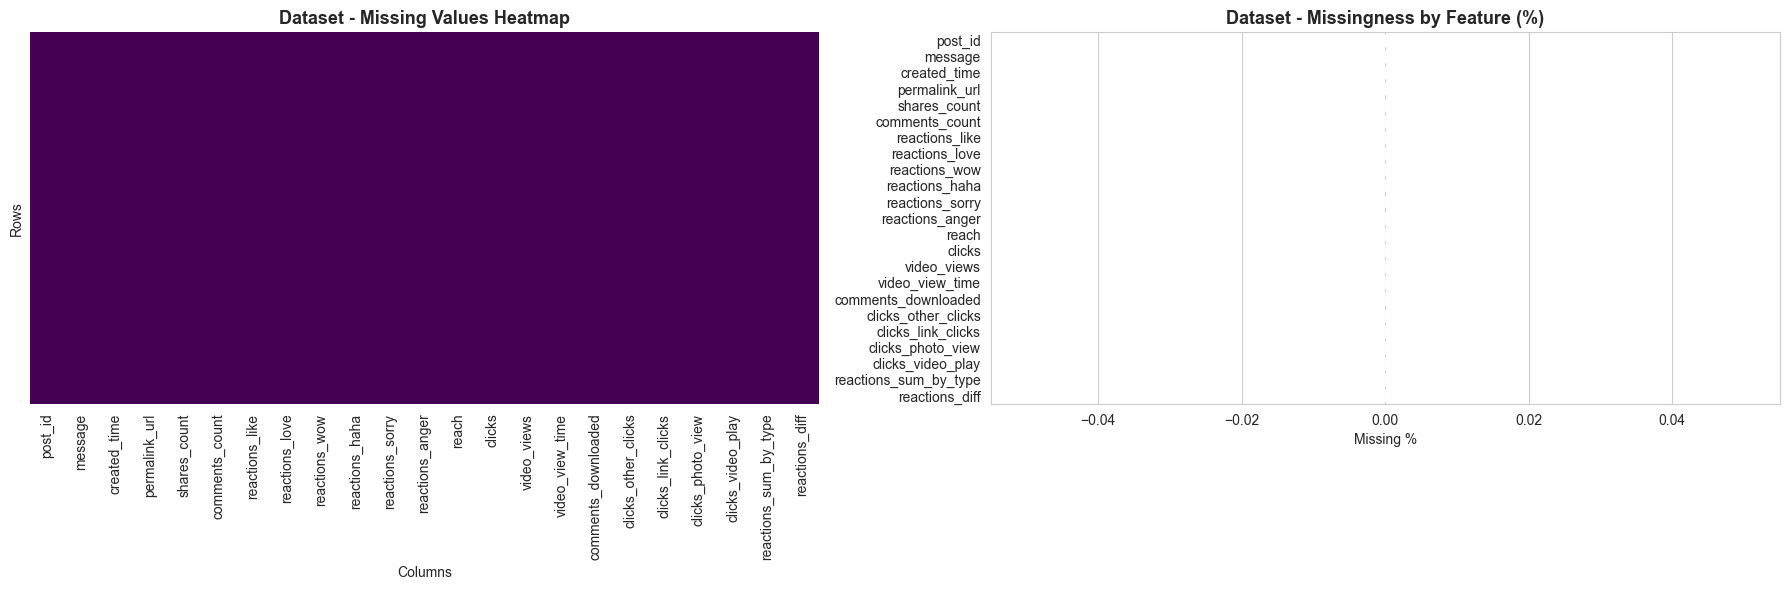

,feature,missing_pct,missing_count
0,post_id,0.0,0
1,message,0.0,0
2,created_time,0.0,0
3,permalink_url,0.0,0
4,shares_count,0.0,0
5,comments_count,0.0,0
6,reactions_like,0.0,0
7,reactions_love,0.0,0
8,reactions_wow,0.0,0
9,reactions_haha,0.0,0


In [27]:
missingness_and_bias_report(fb_posts_clean)

In [ ]:
# Parse Facebook post datetime and derive date-related features
fb_posts_clean["created_time_dt"] = pd.to_datetime(fb_posts_clean["created_time"], errors="coerce", utc=True)

fb_posts_clean["created_date"] = fb_posts_clean["created_time_dt"].dt.date
fb_posts_clean["day_of_month"] = fb_posts_clean["created_time_dt"].dt.day.astype("Int64")
fb_posts_clean["day_of_week"] = fb_posts_clean["created_time_dt"].dt.day_name()
fb_posts_clean["time_of_day"] = fb_posts_clean["created_time_dt"].dt.hour

fb_posts_clean[["created_time", "created_time_dt", "created_date", "day_of_month", "day_of_week", "time_of_day", 'timestamp']].head()

,created_time,created_time_dt,created_date,day_of_month,day_of_week,time_of_day,timestamp
0,2026-03-17T12:45:11+0000,2026-03-17 12:45:11+00:00,2026-03-17,17,Tuesday,12,<bound method DatetimeProperties.to_pydatetime...
1,2026-02-27T16:00:13+0000,2026-02-27 16:00:13+00:00,2026-02-27,27,Friday,16,<bound method DatetimeProperties.to_pydatetime...
2,2026-02-25T19:33:14+0000,2026-02-25 19:33:14+00:00,2026-02-25,25,Wednesday,19,<bound method DatetimeProperties.to_pydatetime...
3,2026-02-22T10:58:39+0000,2026-02-22 10:58:39+00:00,2026-02-22,22,Sunday,10,<bound method DatetimeProperties.to_pydatetime...
4,2026-03-12T14:52:57+0000,2026-03-12 14:52:57+00:00,2026-03-12,12,Thursday,14,<bound method DatetimeProperties.to_pydatetime...


In [39]:
fb_posts_clean.head()

,post_id,message,created_time,permalink_url,shares_count,comments_count,reactions_like,reactions_love,reactions_wow,reactions_haha,reactions_sorry,reactions_anger,reach,clicks,video_views,video_view_time,comments_downloaded,clicks_other_clicks,clicks_link_clicks,clicks_photo_view,clicks_video_play,reactions_sum_by_type,reactions_diff,created_time_dt,created_date,day_of_month,day_of_week,time_of_day,timestamp
0,1686085491707042_1460530322105908,Quando si sbaglia è importante riconoscerlo.,2026-03-17T12:45:11+0000,https://www.facebook.com/reel/1607929663795233/,181.0,50,2917.0,69.0,3.0,577.0,1.0,1.0,139857,4487,68804,9.950623e+08,1,4487.0,0.0,0.0,0.0,3568.0,-161.0,2026-03-17 12:45:11+00:00,2026-03-17,17,Tuesday,12,<bound method DatetimeProperties.to_pydatetime...
1,1686085491707042_1447128706779403,#adv Non so se sul lungo mare di Sanremo abbia...,2026-02-27T16:00:13+0000,https://www.facebook.com/reel/1190230669855920/,2.0,2,379.0,7.0,2.0,5.0,0.0,0.0,147533,379,59426,6.983754e+08,1,379.0,0.0,0.0,0.0,393.0,-22.0,2026-02-27 16:00:13+00:00,2026-02-27,27,Friday,16,<bound method DatetimeProperties.to_pydatetime...
2,1686085491707042_1445563560269251,#adv Oggi ho giocato a gira la moda in real li...,2026-02-25T19:33:14+0000,https://www.facebook.com/reel/2078820786236877/,0.0,0,458.0,12.0,1.0,4.0,0.0,0.0,137359,480,41820,7.062963e+08,1,480.0,0.0,0.0,0.0,475.0,-35.0,2026-02-25 19:33:14+00:00,2026-02-25,25,Wednesday,19,<bound method DatetimeProperties.to_pydatetime...
3,1686085491707042_1442825210543086,Alla domanda se mi hanno fatto mai pesare di n...,2026-02-22T10:58:39+0000,https://www.facebook.com/reel/1277019334244260/,76.0,97,3256.0,258.0,0.0,7.0,0.0,1.0,171102,17647,98276,3.606625e+09,1,17645.0,2.0,0.0,0.0,3522.0,-198.0,2026-02-22 10:58:39+00:00,2026-02-22,22,Sunday,10,<bound method DatetimeProperties.to_pydatetime...
4,1686085491707042_1456809062478034,Sul canale YouTube è uscita una nuova game nig...,2026-03-12T14:52:57+0000,https://www.facebook.com/reel/2459345087847821/,3.0,0,301.0,7.0,0.0,7.0,0.0,1.0,105260,390,36343,5.790440e+08,1,390.0,0.0,0.0,0.0,316.0,-17.0,2026-03-12 14:52:57+00:00,2026-03-12,12,Thursday,14,<bound method DatetimeProperties.to_pydatetime...


# 1.2 Data Cleaning Facebook Comments

In [40]:
fb_comments.describe()

,like_count,from_id,comment_count
count,394084.000000,3.940840e+05,394084.000000
mean,0.982473,2.710868e+16,0.414346
std,19.666574,5.043731e+15,1.240763
min,0.000000,4.842730e+10,0.000000
25%,0.000000,2.609668e+16,0.000000
50%,0.000000,2.634542e+16,0.000000
75%,1.000000,2.682158e+16,0.000000
max,6292.000000,7.829538e+16,148.000000



=== Dataset : MISSINGNESS REPORT ===
Dataset shape: (394084, 9)
Overall missingness: 6.82% of all cells

      feature  missing_pct  missing_count
    parent_id    59.452046         234291
      message     1.959988           7724
   comment_id     0.000000              0
   like_count     0.000000              0
      post_id     0.000000              0
 created_time     0.000000              0
    from_name     0.000000              0
      from_id     0.000000              0
comment_count     0.000000              0


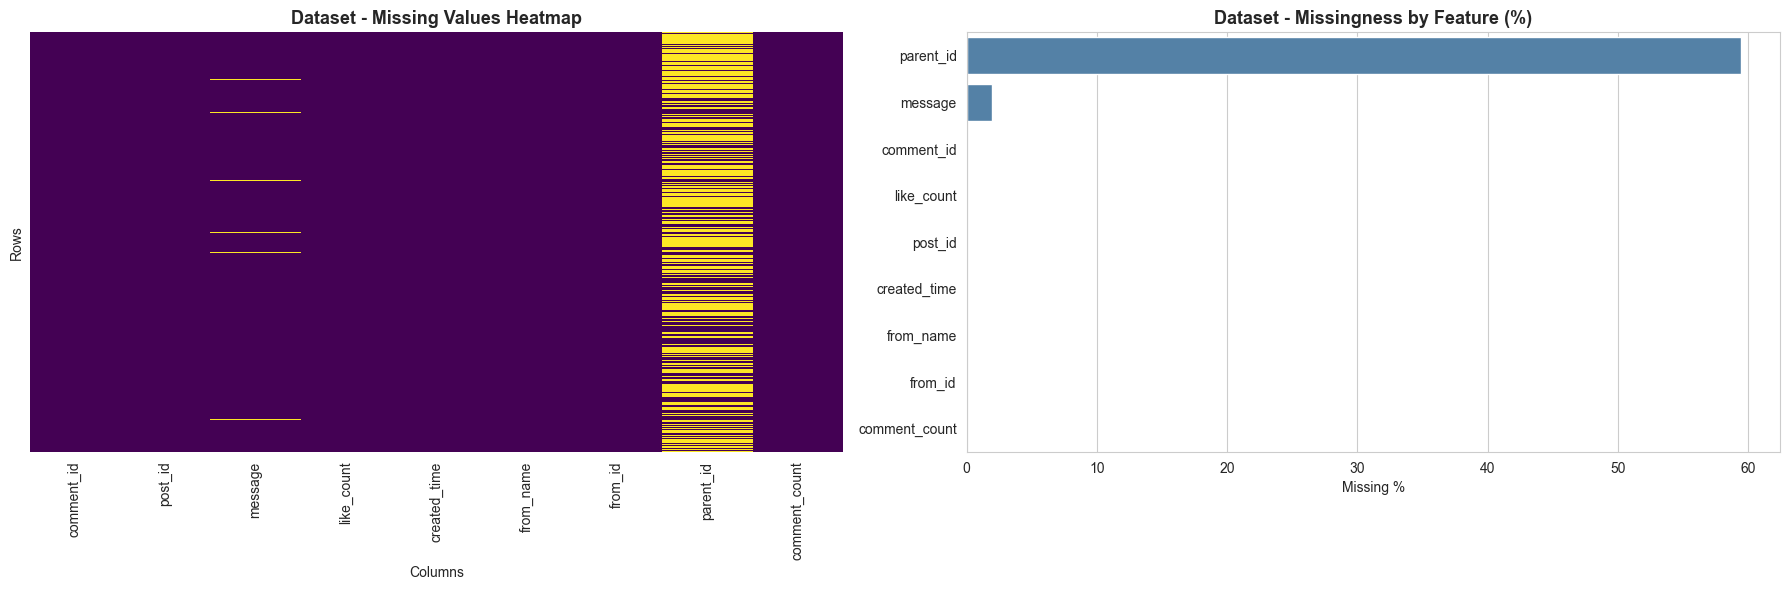

,feature,missing_pct,missing_count
0,parent_id,59.452046,234291
1,message,1.959988,7724
2,comment_id,0.000000,0
3,like_count,0.000000,0
4,post_id,0.000000,0
5,created_time,0.000000,0
6,from_name,0.000000,0
7,from_id,0.000000,0
8,comment_count,0.000000,0


In [41]:
missingness_and_bias_report(fb_comments)

In [42]:
fb_comments_clean = fb_comments.copy()

In [43]:
fb_comments_clean["message"] = fb_comments_clean["message"].fillna("no_message")

print("Remaining NaN in fb_comments_clean['message']:", fb_comments_clean["message"].isna().sum())

Remaining NaN in fb_comments_clean['message']: 0


In [44]:
fb_comments_clean["parent_id"] = fb_comments_clean["parent_id"].fillna("zero_lvl_comment")

print("Remaining NaN in fb_comments_clean['parent_id']:", fb_comments_clean["parent_id"].isna().sum())

Remaining NaN in fb_comments_clean['parent_id']: 0



=== Dataset : MISSINGNESS REPORT ===
Dataset shape: (394084, 9)
Overall missingness: 0.00% of all cells

      feature  missing_pct  missing_count
   comment_id          0.0              0
      post_id          0.0              0
      message          0.0              0
   like_count          0.0              0
 created_time          0.0              0
    from_name          0.0              0
      from_id          0.0              0
    parent_id          0.0              0
comment_count          0.0              0


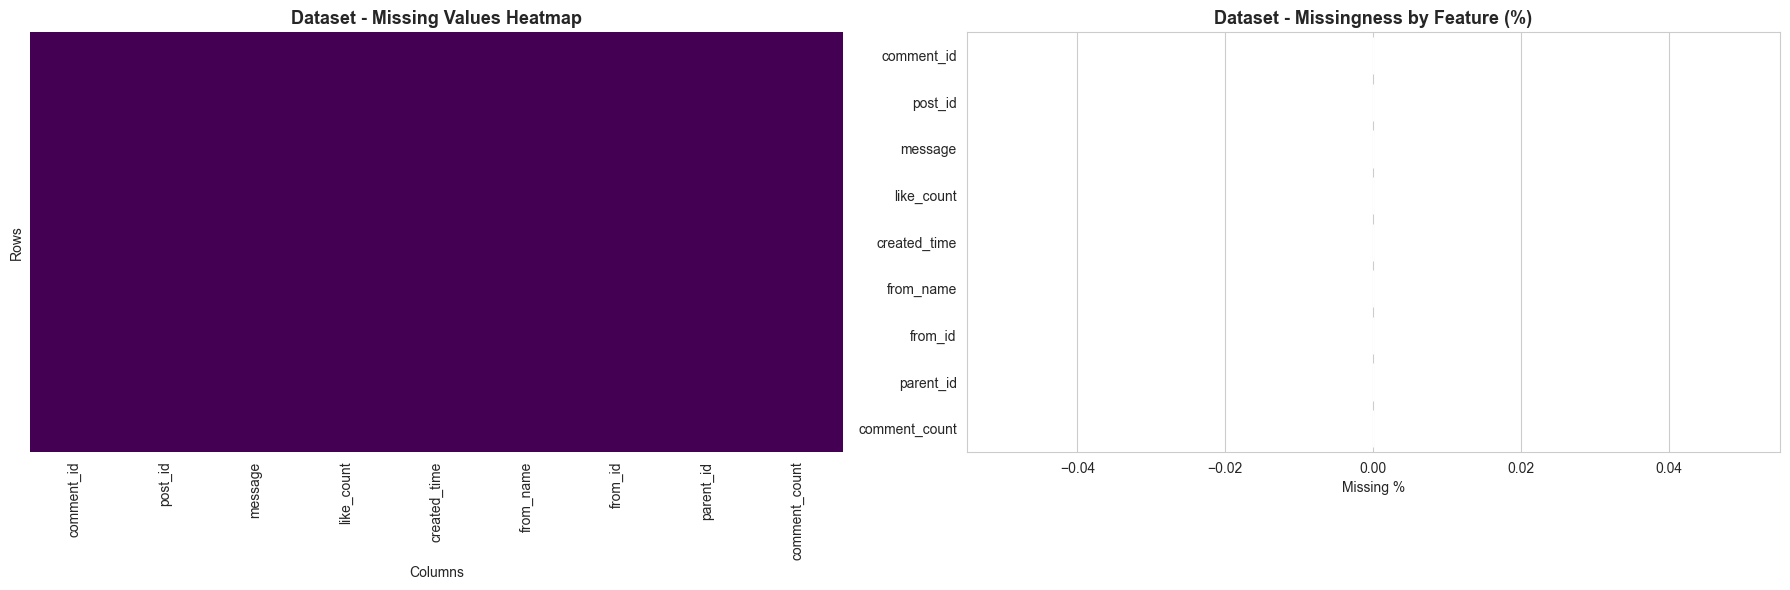

,feature,missing_pct,missing_count
0,comment_id,0.0,0
1,post_id,0.0,0
2,message,0.0,0
3,like_count,0.0,0
4,created_time,0.0,0
5,from_name,0.0,0
6,from_id,0.0,0
7,parent_id,0.0,0
8,comment_count,0.0,0


In [45]:
missingness_and_bias_report(fb_comments_clean)

In [15]:
fb_posts_clean = pd.read_pickle(f"{data_path}Cleaned/fb_posts_clean.pkl")
fb_comments_clean = pd.read_pickle(f"{data_path}Cleaned/fb_comments_clean.pkl")

In [16]:
def _make_unique_columns(cols):
    counts = {}
    out = []
    for c in cols:
        if c in counts:
            counts[c] += 1
            out.append(f"{c}_{counts[c]}")
        else:
            counts[c] = 0
            out.append(c)
    return out

def _to_datetime(s):
    dt = pd.to_datetime(s, errors="coerce", utc=True)
    return dt.dt.tz_convert(None)

def _apply_dtypes(df, dtype_map, label=""):
    for col, dtype in dtype_map.items():
        if col not in df.columns:
            continue
        if dtype == "datetime":
            df[col] = _to_datetime(df[col])
        elif dtype == "bool":
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .str.lower()
                .isin(["true", "1", "yes", "y", "t"])
            )
        elif dtype == "Int64":
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")
        else:
            df[col] = df[col].astype(dtype)
    if label:
        print(f"Done dtype conversion for: {label}")

# Comments dtype map
comments_dtype_map = {
    "message": "string",
    "like_count": "Int64",
    "created_time": "datetime",
    "from_name": "string",
    "from_id": "string",
    "parent_id": "string",
    "comment_count": "Int64",
}
_apply_dtypes(fb_comments_clean, comments_dtype_map, label="comments")

# Posts dtype map
posts_dtype_map = {
    "message": "string",
    "created_time": "datetime",
    "like_count": "Int64",
    "created_date": "datetime",
    "day_of_month": "Int64",
    "day_of_week": "string",
    "time_of_day": "string",
}
_apply_dtypes(fb_posts_clean, posts_dtype_map, label="posts")

print("Comments info:")
fb_comments_clean.info()
print("\nPosts info:")
fb_posts_clean.info()


Done dtype conversion for: comments
Done dtype conversion for: posts
Comments info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 394084 entries, 0 to 394083
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   comment_id     394084 non-null  object        
 1   post_id        394084 non-null  object        
 2   message        394084 non-null  string        
 3   like_count     394084 non-null  Int64         
 4   created_time   394084 non-null  datetime64[ns]
 5   from_name      394084 non-null  string        
 6   from_id        394084 non-null  string        
 7   parent_id      394084 non-null  string        
 8   comment_count  394084 non-null  Int64         
dtypes: Int64(2), datetime64[ns](1), object(2), string(4)
memory usage: 27.8+ MB

Posts info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 29 columns):
 #   Column                 Non-Nul

## Storing in Pickles

In [17]:
cleaned_path = os.path.join(data_path, "Cleaned")
os.makedirs(cleaned_path, exist_ok=True)

fb_posts_clean.to_pickle(os.path.join(cleaned_path, "fb_posts_clean.pkl"))
fb_comments_clean.to_pickle(os.path.join(cleaned_path, "fb_comments_clean.pkl"))

print(f"Saved cleaned files to: {cleaned_path}")

Saved cleaned files to: D:\Polythecninco di Milano\AFB_Lab\Data\Camihawke\\Cleaned


## 2. Data Cleaning - TikTok Posts

In [74]:
print("=== TIKTOK POSTS ===")
print(f"Shape: {tk_posts.shape}")
print(f"\nFirst few rows:")
print(tk_posts.head())
print(f"\nData types:\n{tk_posts.dtypes}")
print(f"\nMissing values:\n{tk_posts.isnull().sum()}")
print(f"\nBasic statistics:\n{tk_posts.describe()}")

=== TIKTOK POSTS ===
Shape: (335, 9)

First few rows:
              media_id creation_date  create_time  \
0  7064578287548337414    2022-02-14          NaN   
1  7136966601173191941    2022-08-28          NaN   
2  7139846435318549766    2022-09-05          NaN   
3  7140665802436463878    2022-09-07          NaN   
4  7142831623606684933    2022-09-13          NaN   

                                             caption  comments_count  \
0  #lasdivinas @alicelikeaudrey @guglielmoscillal...            1135   
1  #necromassalegnosa #biodiversity necromassaleg...               5   
2                                BENTORNATA A CASA❣️             109   
3                        E di nuovo tempo di Zucca!               95   
4      #perte #fotofunny #cie  perte #fotofunny #cie              37   

   like_count    views  shares  comments_downloaded  
0      200000  2200000    7057                    1  
1        1175    40500       3                    1  
2       45300   521300     319  

In [67]:
tk_posts.head()

,media_id,creation_date,create_time,caption,comments_count,like_count,views,shares,comments_downloaded
0,7064578287548337414,2022-02-14,NaN,#lasdivinas @alicelikeaudrey @guglielmoscillal...,1135,200000,2200000,7057,1
1,7136966601173191941,2022-08-28,NaN,#necromassalegnosa #biodiversity necromassaleg...,5,1175,40500,3,1
2,7139846435318549766,2022-09-05,NaN,BENTORNATA A CASA❣️,109,45300,521300,319,1
3,7140665802436463878,2022-09-07,NaN,E di nuovo tempo di Zucca!,95,22100,330200,231,1
4,7142831623606684933,2022-09-13,NaN,#perte #fotofunny #cie perte #fotofunny #cie,37,8347,134100,36,1



=== Dataset : MISSINGNESS REPORT ===
Dataset shape: (335, 9)
Overall missingness: 9.65% of all cells

            feature  missing_pct  missing_count
        create_time    82.985075            278
            caption     3.880597             13
           media_id     0.000000              0
      creation_date     0.000000              0
     comments_count     0.000000              0
         like_count     0.000000              0
              views     0.000000              0
             shares     0.000000              0
comments_downloaded     0.000000              0


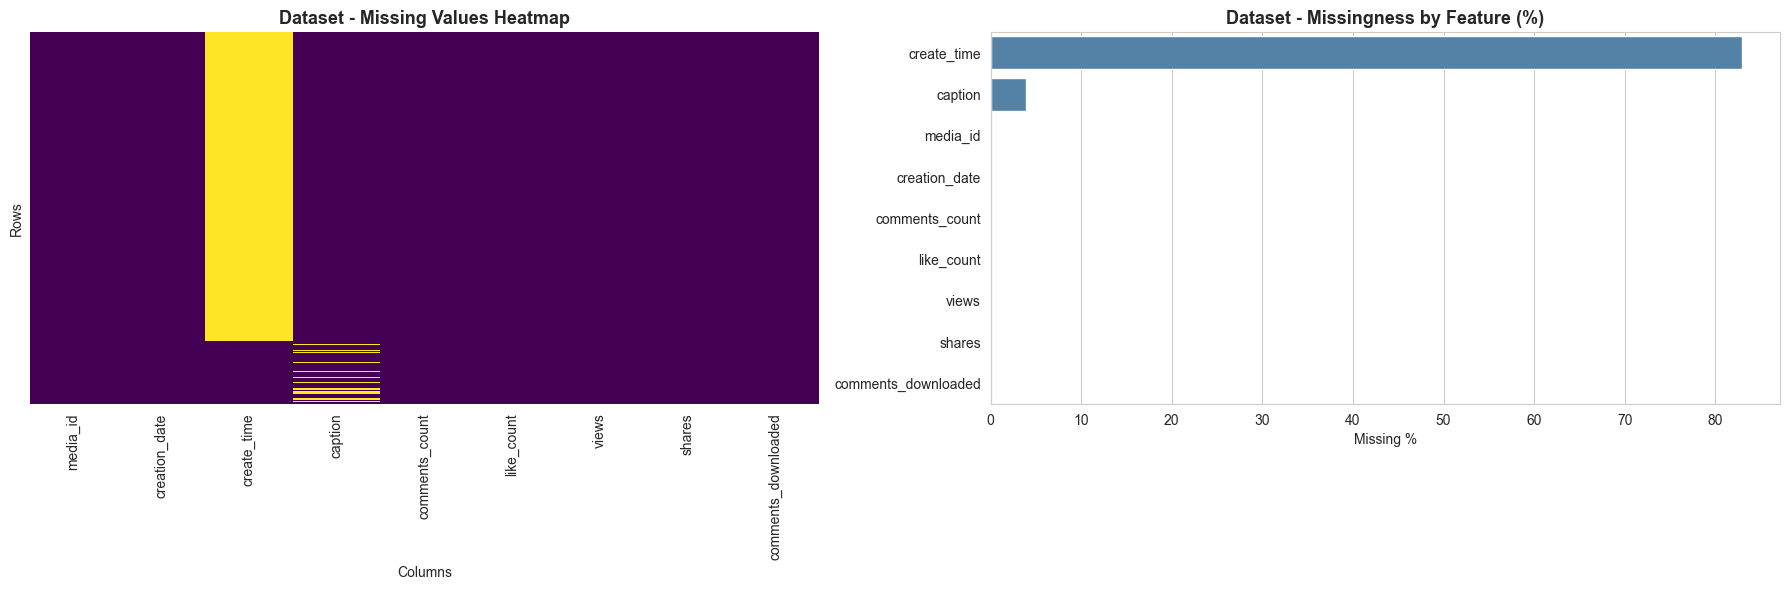

,feature,missing_pct,missing_count
0,create_time,82.985075,278
1,caption,3.880597,13
2,media_id,0.000000,0
3,creation_date,0.000000,0
4,comments_count,0.000000,0
5,like_count,0.000000,0
6,views,0.000000,0
7,shares,0.000000,0
8,comments_downloaded,0.000000,0


In [75]:
missingness_and_bias_report(tk_posts)

In [76]:
tk_posts.describe()

,media_id,create_time,comments_count,like_count,views,shares,comments_downloaded
count,3.350000e+02,5.700000e+01,335.000000,3.350000e+02,3.350000e+02,335.000000,335.0
mean,7.310481e+18,1.626962e+09,212.817910,4.046853e+04,4.661194e+05,1779.405970,1.0
std,2.212020e+17,3.928101e+07,1610.818455,2.923560e+05,2.773792e+06,14454.552342,0.0
min,6.781435e+18,1.578926e+09,0.000000,9.400000e+01,1.878000e+03,0.000000,1.0
25%,7.177691e+18,1.587745e+09,13.000000,2.735500e+03,5.620000e+04,19.500000,1.0
50%,7.292352e+18,1.630416e+09,37.000000,7.638000e+03,1.375000e+05,99.000000,1.0
75%,7.514159e+18,1.650381e+09,91.500000,2.270300e+04,3.264500e+05,472.000000,1.0
max,7.618933e+18,1.773921e+09,28400.000000,4.300000e+06,4.350000e+07,223100.000000,1.0


In [78]:
tk_posts_clean = tk_posts.copy()

In [80]:
tk_posts_clean.drop(columns=["create_time"], inplace=True)

In [85]:
tk_posts_clean["caption"] = tk_posts_clean["caption"].fillna("no_caption")

print("Remaining NaN in tk_posts_clean['caption']:", tk_posts_clean["caption"].isna().sum())

Remaining NaN in tk_posts_clean['caption']: 0



=== Dataset : MISSINGNESS REPORT ===
Dataset shape: (335, 8)
Overall missingness: 0.00% of all cells

            feature  missing_pct  missing_count
           media_id          0.0              0
      creation_date          0.0              0
            caption          0.0              0
     comments_count          0.0              0
         like_count          0.0              0
              views          0.0              0
             shares          0.0              0
comments_downloaded          0.0              0


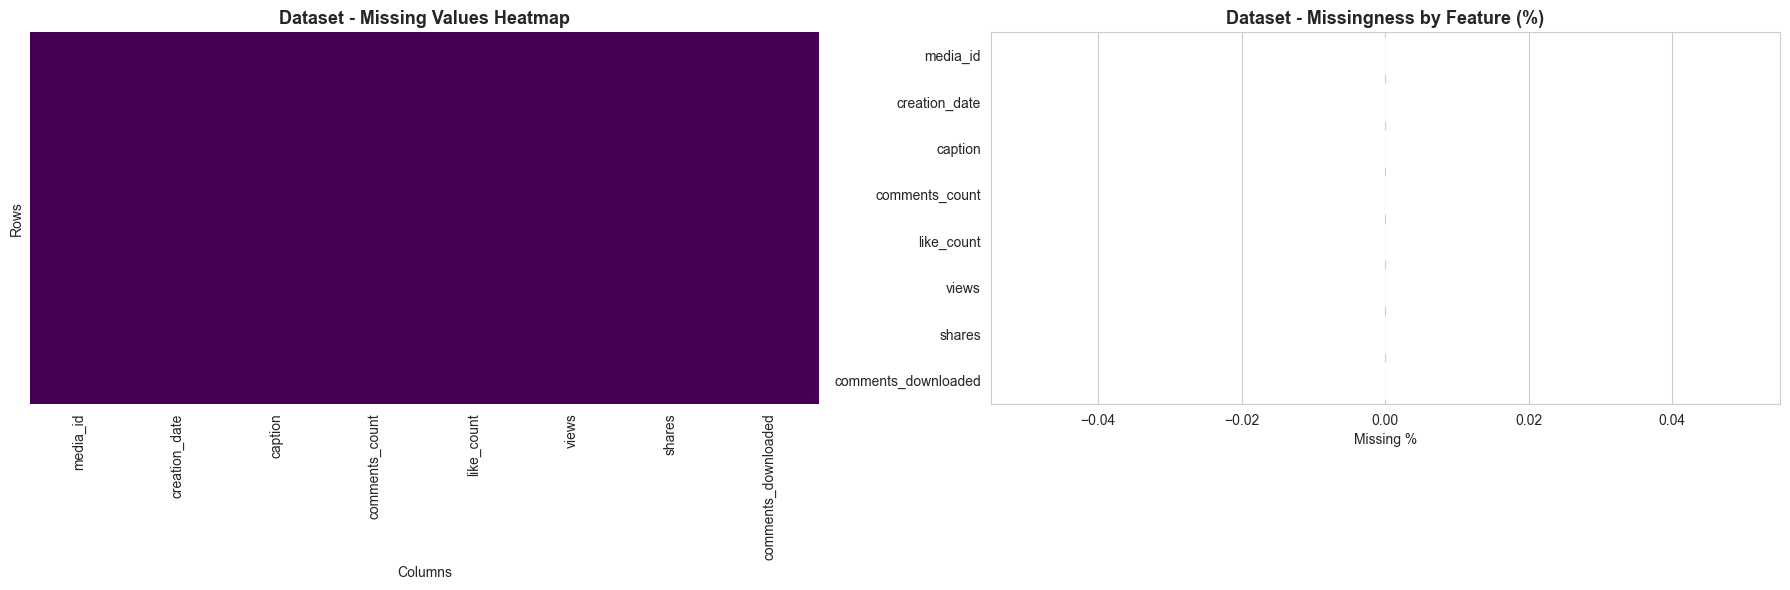

,feature,missing_pct,missing_count
0,media_id,0.0,0
1,creation_date,0.0,0
2,caption,0.0,0
3,comments_count,0.0,0
4,like_count,0.0,0
5,views,0.0,0
6,shares,0.0,0
7,comments_downloaded,0.0,0


In [86]:
missingness_and_bias_report(tk_posts_clean)

# 2.2 Data Cleaning Tiktok Comments

In [87]:
tk_comments.describe()

,cid,media_id,create_time,digg_count,uid,reply_comment_total,reply_id,reply_to_reply_id,is_author_digged,author_pin
count,1.965400e+04,1.965400e+04,1.965400e+04,19654.000000,1.965400e+04,19654.000000,19654.0,19654.0,19654.000000,19654.0
mean,7.292149e+18,7.286795e+18,1.697836e+09,18.014246,6.042831e+18,0.204437,0.0,0.0,0.150198,0.0
std,2.127944e+17,2.140331e+17,4.954507e+07,207.285402,2.231445e+18,1.061402,0.0,0.0,0.357275,0.0
min,6.781436e+18,6.781435e+18,1.578926e+09,0.000000,1.616375e+06,0.000000,0.0,0.0,0.000000,0.0
25%,7.183029e+18,7.168891e+18,1.672429e+09,0.000000,6.726214e+18,0.000000,0.0,0.0,0.000000,0.0
50%,7.258555e+18,7.257834e+18,1.690014e+09,0.000000,6.807768e+18,0.000000,0.0,0.0,0.000000,0.0
75%,7.496931e+18,7.491704e+18,1.745515e+09,1.000000,6.959648e+18,0.000000,0.0,0.0,0.000000,0.0
max,7.619076e+18,7.618933e+18,1.773954e+09,12657.000000,7.594223e+18,36.000000,0.0,0.0,1.000000,0.0


In [68]:
tk_comments.head()

,cid,media_id,text,create_time,digg_count,nickname,uid,comment_language,reply_comment_total,reply_id,reply_to_reply_id,is_author_digged,author_pin
0,7618640617301050134,7618582897959783702,vero?\nho un elenco identico...😅,1773853020,4,Laura 🤪,7213726581705884678,it,0,0,0,1,0
1,7618584919522706198,7618582897959783702,IDEM!,1773840051,4,Roby,6908466011760247810,pl,0,0,0,1,0
2,7618639296828080919,7618582897959783702,🤣🤣🤣🤣🤣🤣,1773852700,0,💜🧿 valentain💜🧿,7046706435484353542,un,0,0,0,0,0
3,7618595602678776598,7618582897959783702,è difficile non avere mai torto,1773842533,8,Alice,6799618304623821830,it,2,0,0,0,0
4,7618667284903379734,7618582897959783702,@Someone to Lava💕,1773859220,0,ele,7024167276347032581,un,0,0,0,0,0


In [70]:
# Parse TikTok comment UNIX timestamp and extract date/time features
tk_comments["create_time_dt"] = pd.to_datetime(tk_comments["create_time"], unit="s", errors="coerce", utc=True)

tk_comments["year"] = tk_comments["create_time_dt"].dt.year.astype("Int64")
tk_comments["month"] = tk_comments["create_time_dt"].dt.month.astype("Int64")
tk_comments["day_of_month"] = tk_comments["create_time_dt"].dt.day.astype("Int64")
tk_comments["day_of_week"] = tk_comments["create_time_dt"].dt.day_name()
tk_comments["time_of_day"] = tk_comments["create_time_dt"].dt.hour.astype("Int64")

tk_comments[["create_time", "create_time_dt", "year", "month", "day_of_month", "day_of_week", "time_of_day"]].head()

,create_time,create_time_dt,year,month,day_of_month,day_of_week,time_of_day
0,1773853020,2026-03-18 16:57:00+00:00,2026,3,18,Wednesday,16
1,1773840051,2026-03-18 13:20:51+00:00,2026,3,18,Wednesday,13
2,1773852700,2026-03-18 16:51:40+00:00,2026,3,18,Wednesday,16
3,1773842533,2026-03-18 14:02:13+00:00,2026,3,18,Wednesday,14
4,1773859220,2026-03-18 18:40:20+00:00,2026,3,18,Wednesday,18


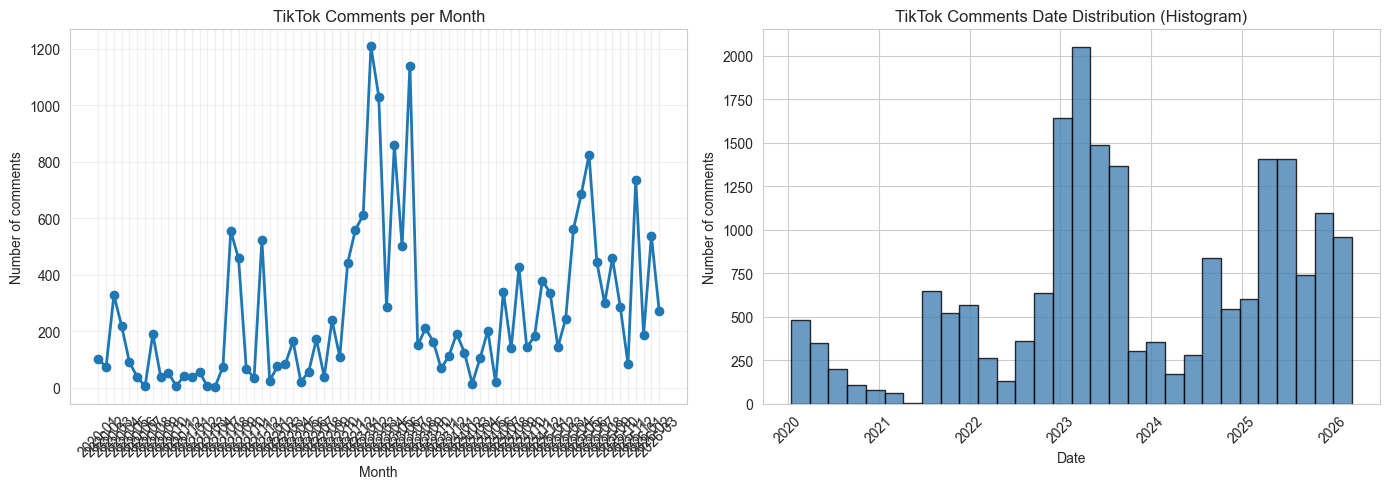

=== TikTok Comments Timeline Summary ===
Total comments: 19654
Date range: 2020-01-13 14:34:25+00:00 to 2026-03-19 21:07:16+00:00

Comments per month:
create_time_dt
2020-01    101
2020-02     73
2020-03    328
2020-04    217
2020-05     89
          ... 
2025-11     82
2025-12    737
2026-01    187
2026-02    537
2026-03    272
Freq: M, Name: count, Length: 73, dtype: int64


In [71]:
# Distribution of TikTok comments over time
tk_comments_timeline = (
    tk_comments["create_time_dt"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Monthly counts timeline
axes[0].plot(tk_comments_timeline.index.astype(str), tk_comments_timeline.values, marker="o", linewidth=2)
axes[0].set_title("TikTok Comments per Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Number of comments")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.3)

# 2) Histogram of comments over time
axes[1].hist(tk_comments["create_time_dt"].dt.to_pydatetime(), bins=30, color="steelblue", edgecolor="black", alpha=0.8)
axes[1].set_title("TikTok Comments Date Distribution (Histogram)")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Number of comments")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Summary statistics
print("=== TikTok Comments Timeline Summary ===")
print(f"Total comments: {len(tk_comments)}")
print(f"Date range: {tk_comments['create_time_dt'].min()} to {tk_comments['create_time_dt'].max()}")
print(f"\nComments per month:\n{tk_comments_timeline}")

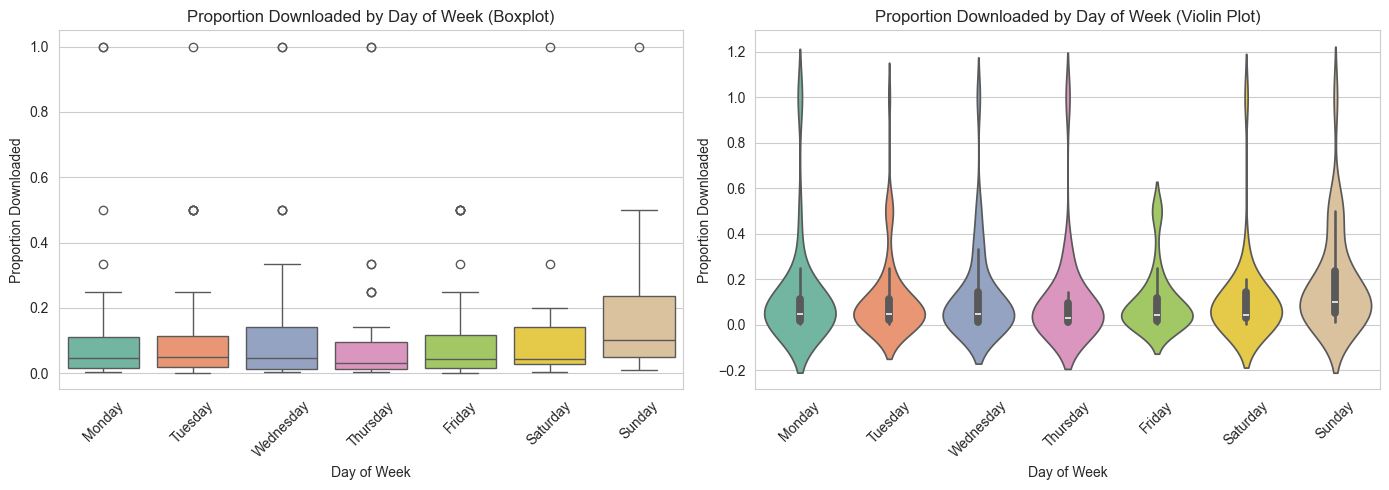

=== Proportion Downloaded by Day of Week ===
             count      mean       std       min       25%       50%  \
day_of_week                                                            
Monday        41.0  0.121158  0.223287  0.001988  0.016949  0.047619   
Tuesday       64.0  0.111438  0.174222  0.001764  0.019545  0.048810   
Wednesday     66.0  0.126805  0.202142  0.004065  0.013866  0.046537   
Thursday      46.0  0.106788  0.210895  0.001969  0.012824  0.029643   
Friday        55.0  0.106828  0.143281  0.001271  0.016393  0.043478   
Saturday      29.0  0.106993  0.186704  0.002012  0.028571  0.043478   
Sunday        30.0  0.186280  0.219247  0.011111  0.050658  0.100000   

                  75%  max  
day_of_week                 
Monday       0.111111  1.0  
Tuesday      0.114583  1.0  
Wednesday    0.142857  1.0  
Thursday     0.094231  1.0  
Friday       0.118056  0.5  
Saturday     0.142857  1.0  
Sunday       0.237500  1.0  


In [74]:
# Distribution of proportion downloaded by day of week
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
tk_posts_with_comments['day_of_week'] = pd.to_datetime(tk_posts_with_comments['creation_date']).dt.day_name()
tk_posts_with_comments['day_of_week'] = pd.Categorical(tk_posts_with_comments['day_of_week'], categories=day_order, ordered=True)

sns.boxplot(data=tk_posts_with_comments, x='day_of_week', y='proportion_downloaded', ax=axes[0], palette='Set2')
axes[0].set_title('Proportion Downloaded by Day of Week (Boxplot)')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Proportion Downloaded')
axes[0].tick_params(axis='x', rotation=45)

# Violin plot by day of week
sns.violinplot(data=tk_posts_with_comments, x='day_of_week', y='proportion_downloaded', ax=axes[1], palette='Set2')
axes[1].set_title('Proportion Downloaded by Day of Week (Violin Plot)')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Proportion Downloaded')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary statistics by day of week
print("=== Proportion Downloaded by Day of Week ===")
print(tk_posts_with_comments.groupby('day_of_week')['proportion_downloaded'].describe())


In [69]:
tk_comments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19654 entries, 0 to 19653
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   cid                  19654 non-null  int64 
 1   media_id             19654 non-null  int64 
 2   text                 19634 non-null  object
 3   create_time          19654 non-null  int64 
 4   digg_count           19654 non-null  int64 
 5   nickname             19650 non-null  object
 6   uid                  19654 non-null  int64 
 7   comment_language     18219 non-null  object
 8   reply_comment_total  19654 non-null  int64 
 9   reply_id             19654 non-null  int64 
 10  reply_to_reply_id    19654 non-null  int64 
 11  is_author_digged     19654 non-null  int64 
 12  author_pin           19654 non-null  int64 
dtypes: int64(10), object(3)
memory usage: 1.9+ MB



=== Dataset : MISSINGNESS REPORT ===
Dataset shape: (19654, 13)
Overall missingness: 0.57% of all cells

            feature  missing_pct  missing_count
   comment_language     7.301313           1435
               text     0.101760             20
           nickname     0.020352              4
                cid     0.000000              0
           media_id     0.000000              0
         digg_count     0.000000              0
        create_time     0.000000              0
                uid     0.000000              0
reply_comment_total     0.000000              0
           reply_id     0.000000              0
  reply_to_reply_id     0.000000              0
   is_author_digged     0.000000              0
         author_pin     0.000000              0


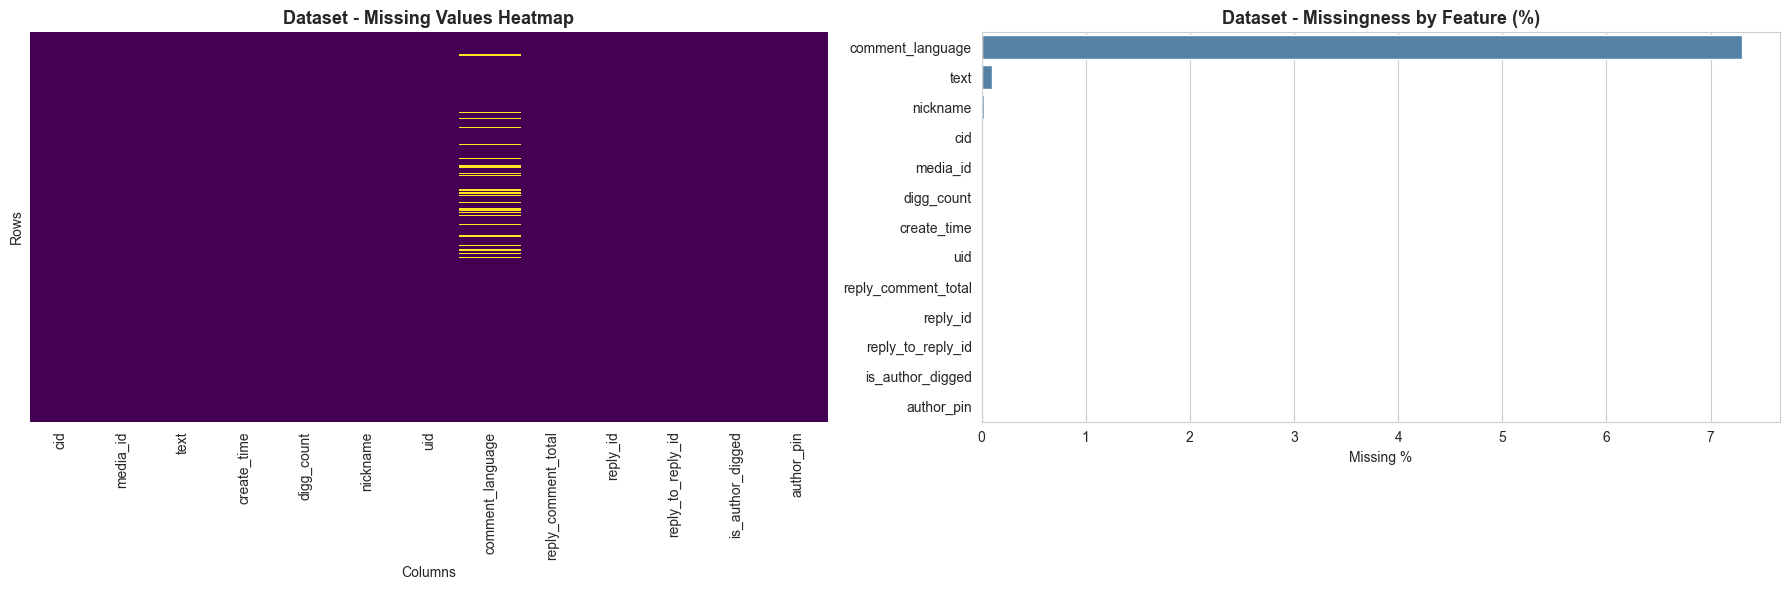

,feature,missing_pct,missing_count
0,comment_language,7.301313,1435
1,text,0.101760,20
2,nickname,0.020352,4
3,cid,0.000000,0
4,media_id,0.000000,0
5,digg_count,0.000000,0
6,create_time,0.000000,0
7,uid,0.000000,0
8,reply_comment_total,0.000000,0
9,reply_id,0.000000,0


In [88]:
missingness_and_bias_report(tk_comments)

In [89]:
tk_comments_clean = tk_comments.copy()

In [95]:
temp_chkpt = tk_comments_clean

In [101]:
#tk_comments_clean = temp_chkpt

In [102]:
tk_comments_clean = tk_comments_clean.dropna(subset=["text"], inplace=False)

In [104]:
tk_comments_clean["nickname"] = tk_comments_clean["nickname"].fillna("no_name")

print("Remaining NaN in tk_comments_clean['nickname']:", tk_comments_clean["nickname"].isna().sum())

Remaining NaN in tk_comments_clean['nickname']: 0


In [107]:
tk_comments_clean["comment_language"] = tk_comments_clean["comment_language"].fillna("emoji/other")

print("Remaining NaN in tk_comments_clean['comment_language']:", tk_comments_clean["comment_language"].isna().sum())

Remaining NaN in tk_comments_clean['comment_language']: 0



=== Dataset : MISSINGNESS REPORT ===
Dataset shape: (19634, 13)
Overall missingness: 0.00% of all cells

            feature  missing_pct  missing_count
                cid          0.0              0
           media_id          0.0              0
               text          0.0              0
        create_time          0.0              0
         digg_count          0.0              0
           nickname          0.0              0
                uid          0.0              0
   comment_language          0.0              0
reply_comment_total          0.0              0
           reply_id          0.0              0
  reply_to_reply_id          0.0              0
   is_author_digged          0.0              0
         author_pin          0.0              0


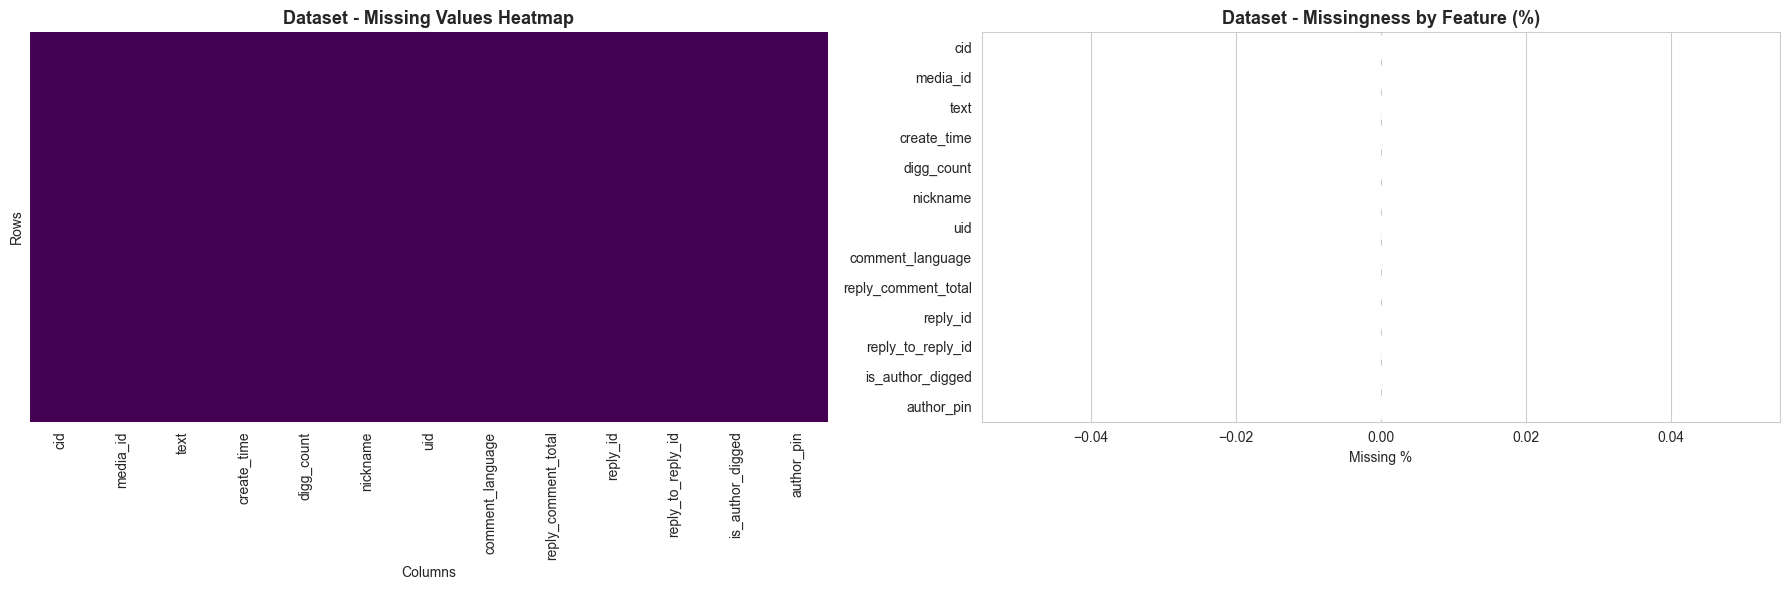

,feature,missing_pct,missing_count
0,cid,0.0,0
1,media_id,0.0,0
2,text,0.0,0
3,create_time,0.0,0
4,digg_count,0.0,0
5,nickname,0.0,0
6,uid,0.0,0
7,comment_language,0.0,0
8,reply_comment_total,0.0,0
9,reply_id,0.0,0


In [108]:
missingness_and_bias_report(tk_comments_clean)

In [109]:
tk_posts_clean.to_pickle(os.path.join(cleaned_path, "tk_posts_clean.pkl"))
tk_comments_clean.to_pickle(os.path.join(cleaned_path, "tk_comments_clean.pkl"))

## 3. Preliminary Visualizations - Facebook Posts

Numeric columns in Facebook Posts: ['shares_count', 'comments_count', 'reactions_count', 'reactions_like', 'reactions_love', 'reactions_wow', 'reactions_haha', 'reactions_sorry', 'reactions_anger', 'reach', 'impressions', 'clicks', 'engaged_users', 'video_views', 'video_view_time', 'comments_downloaded']

Number of numeric columns: 16


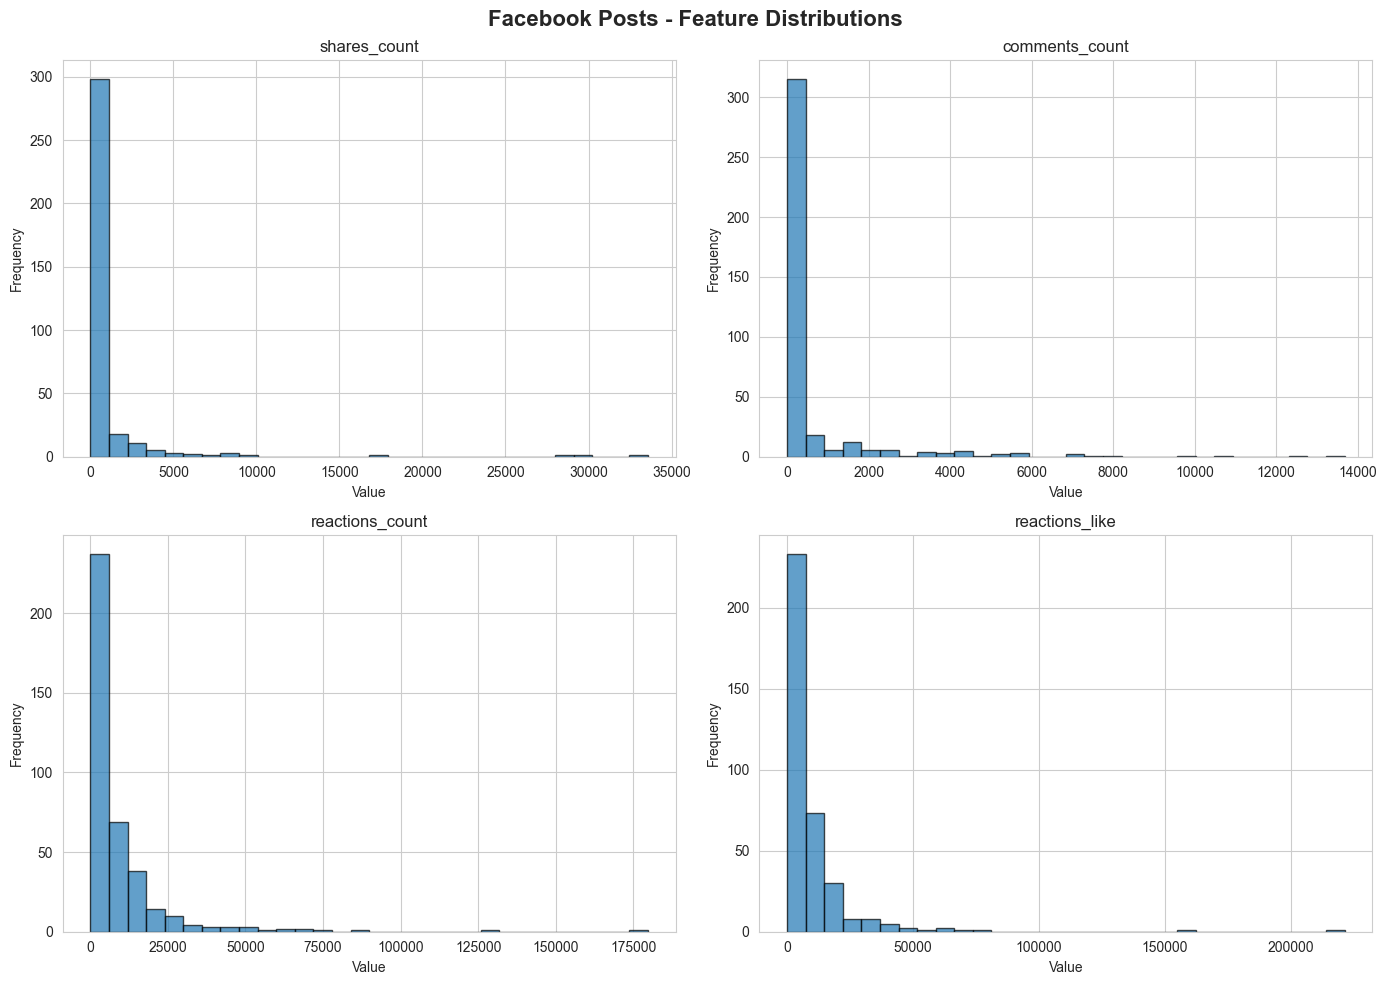


Generating pairplot for Facebook Posts...


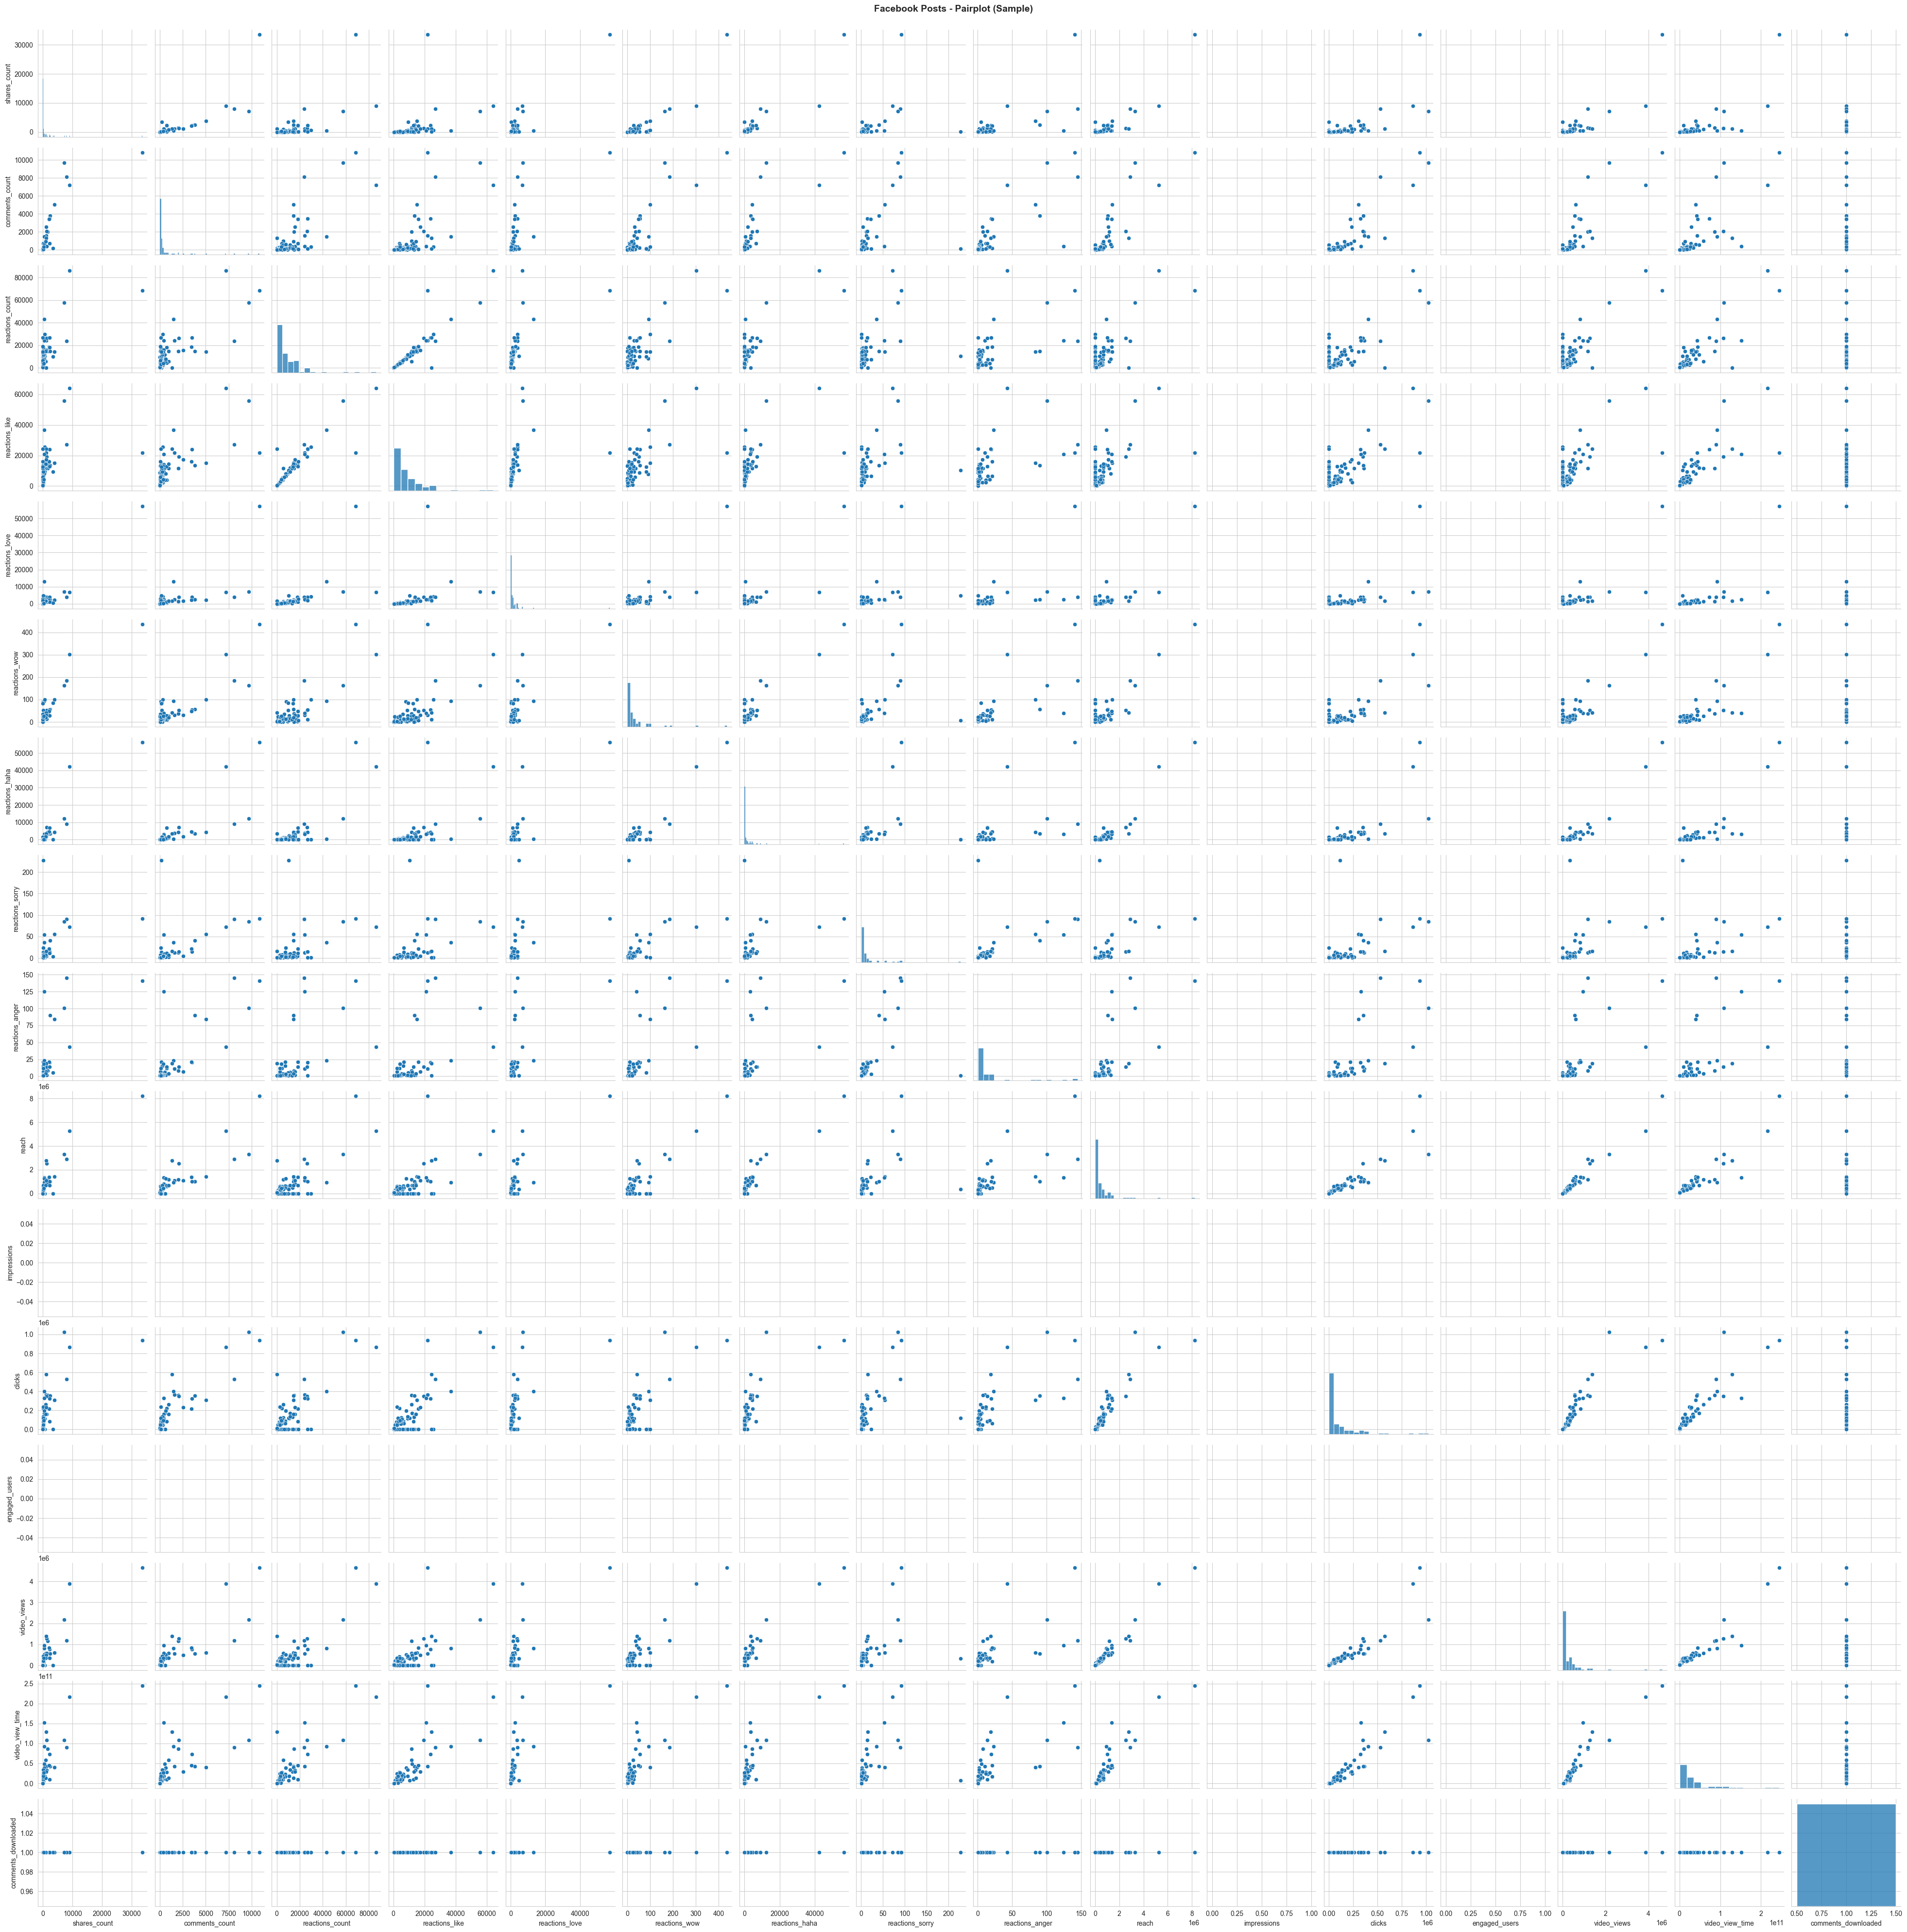

In [6]:
# Select numeric columns for visualization
fb_numeric = fb_posts.select_dtypes(include=[np.number])

print("Numeric columns in Facebook Posts:", fb_numeric.columns.tolist())
print(f"\nNumber of numeric columns: {len(fb_numeric.columns)}")

# Distribution plots for key numeric features
if len(fb_numeric.columns) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Facebook Posts - Feature Distributions', fontsize=16, fontweight='bold')
    axes = axes.ravel()
    
    for idx, col in enumerate(fb_numeric.columns[:4]):
        axes[idx].hist(fb_numeric[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col}')
        axes[idx].set_xlabel('Value')
        axes[idx].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

# Pairplot for numeric features (if we have multiple numeric columns)
if len(fb_numeric.columns) > 1:
    print("\nGenerating pairplot for Facebook Posts...")
    sns.pairplot(fb_numeric.sample(min(100, len(fb_numeric))), diag_kind='hist')
    plt.suptitle('Facebook Posts - Pairplot (Sample)', fontsize=14, fontweight='bold', y=1.001)
    plt.show()

## 4. Preliminary Visualizations - TikTok Posts

Numeric columns in TikTok Posts: ['media_id', 'create_time', 'comments_count', 'like_count', 'views', 'shares', 'comments_downloaded']

Number of numeric columns: 7


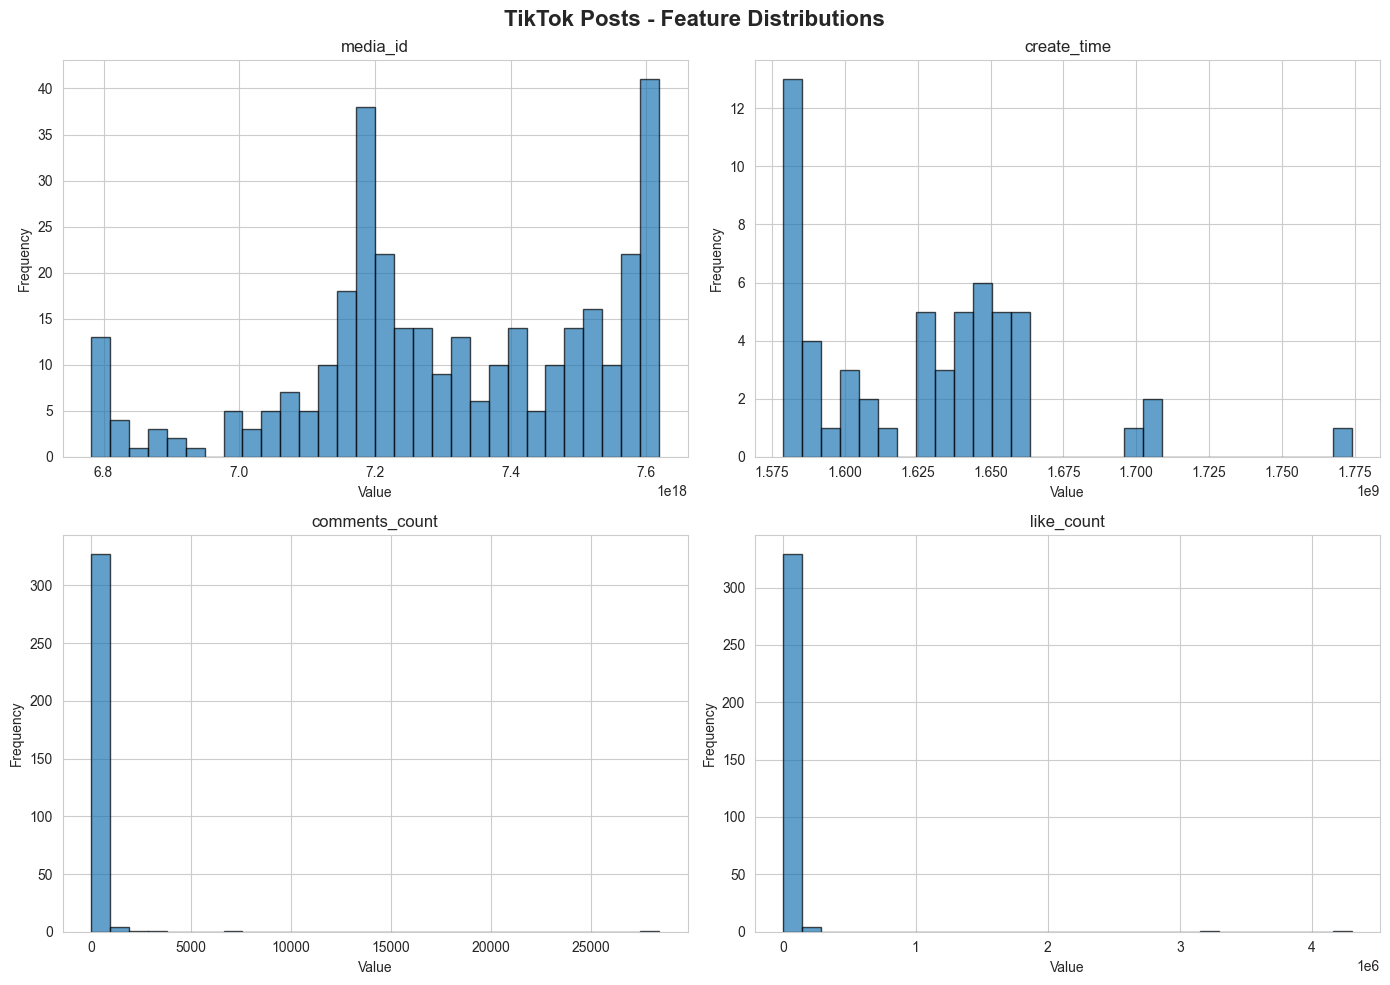


Generating pairplot for TikTok Posts...


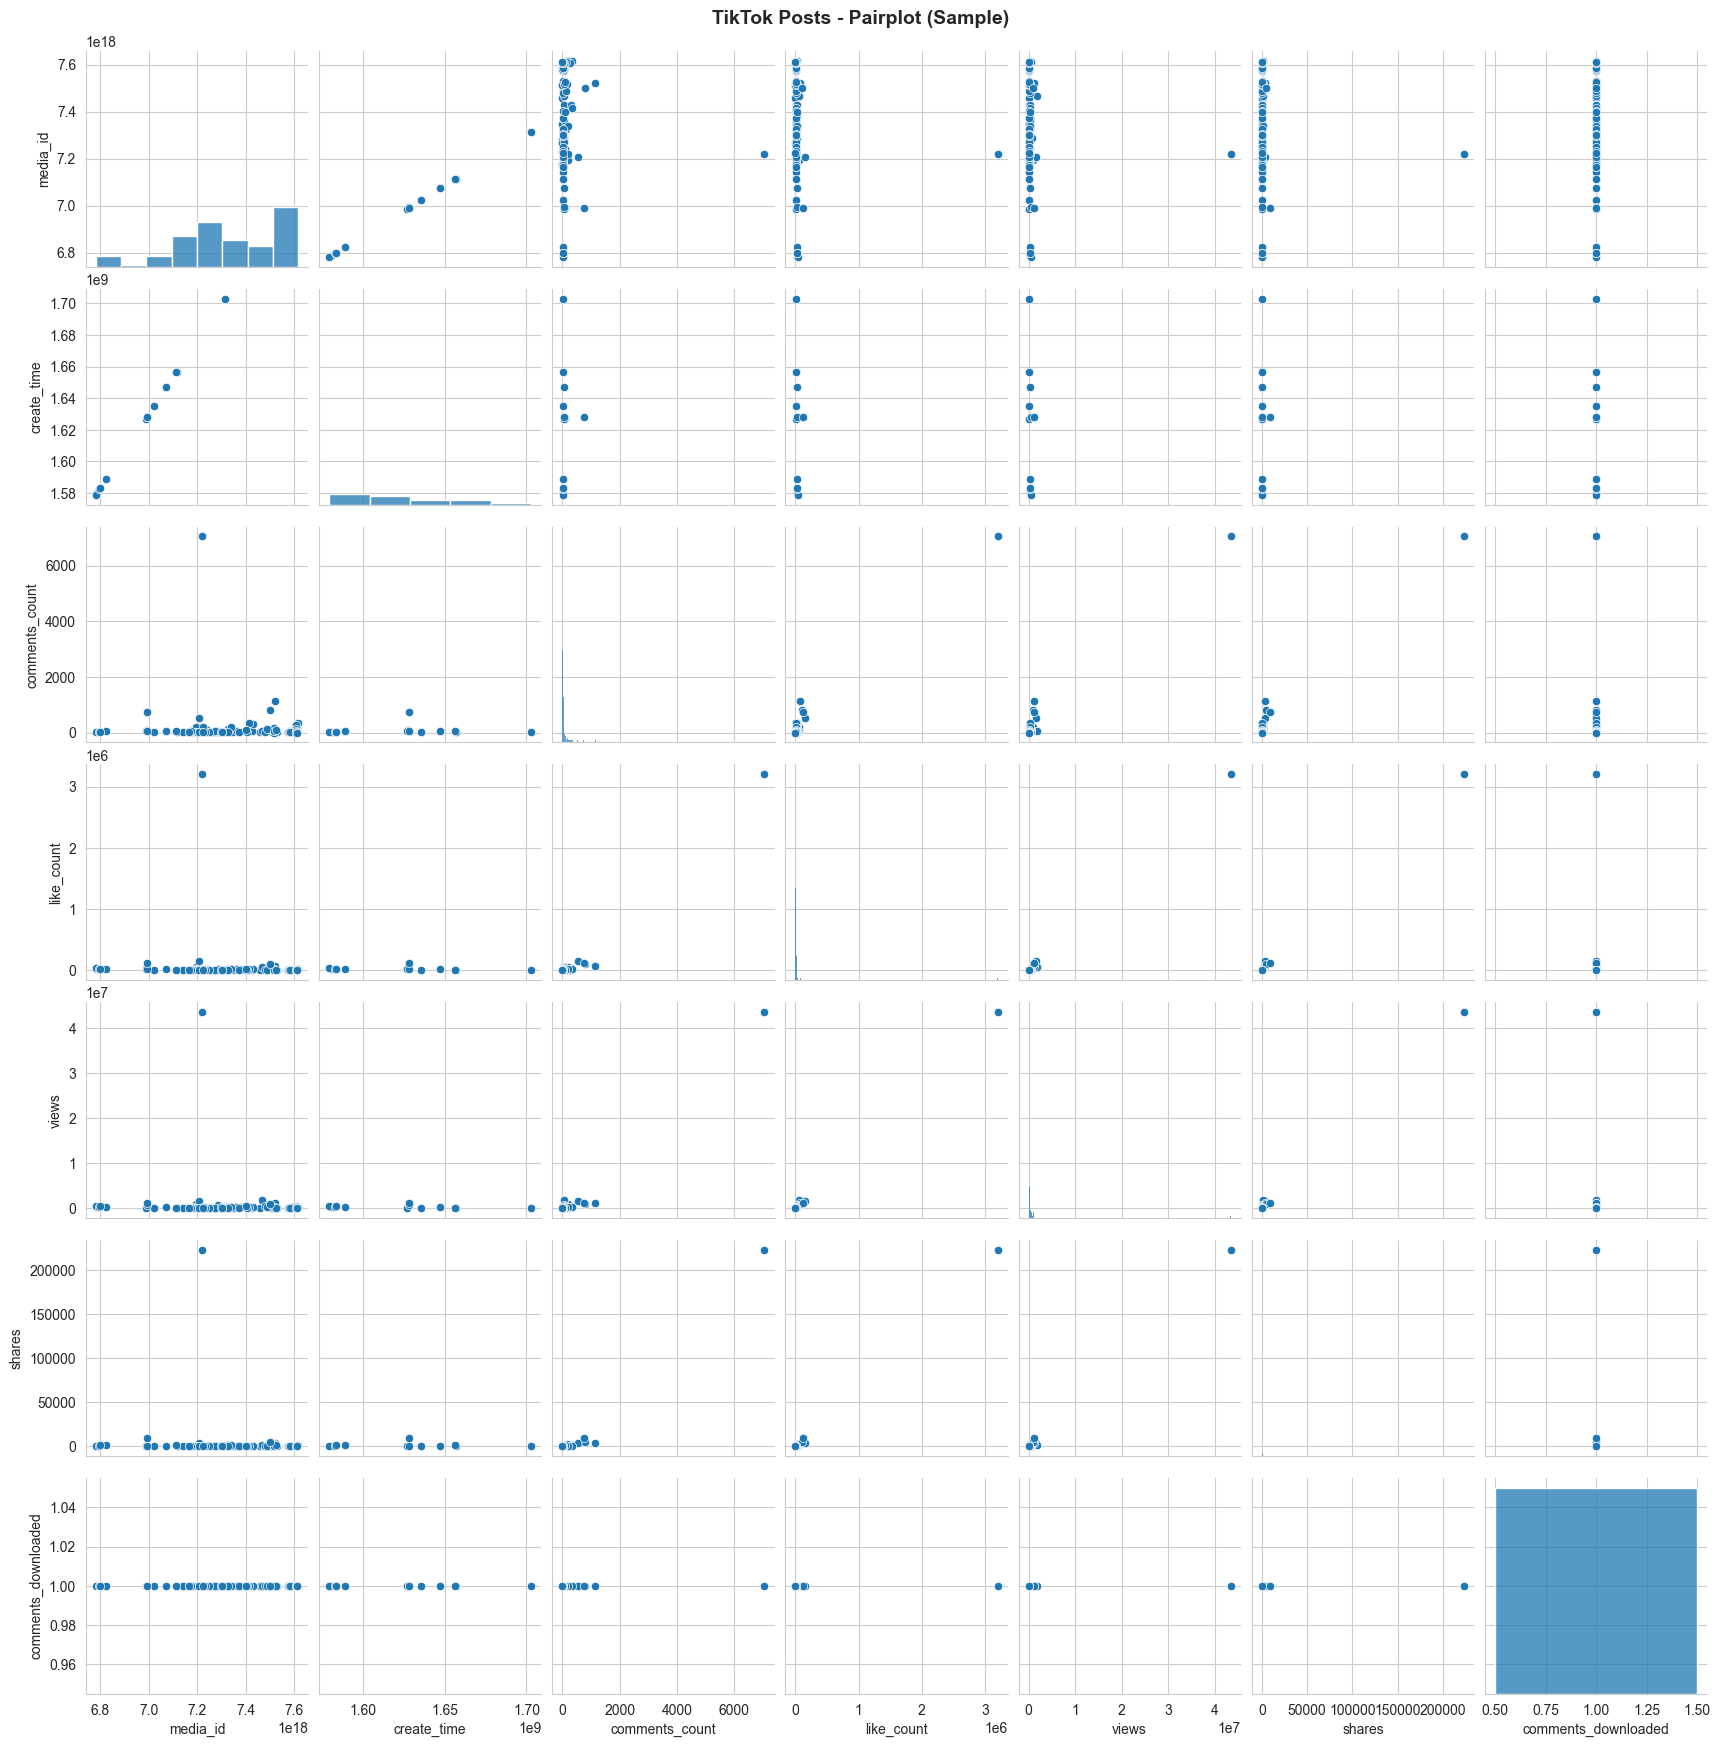

In [7]:
# Select numeric columns for visualization
tk_numeric = tk_posts.select_dtypes(include=[np.number])

print("Numeric columns in TikTok Posts:", tk_numeric.columns.tolist())
print(f"\nNumber of numeric columns: {len(tk_numeric.columns)}")

# Distribution plots for key numeric features
if len(tk_numeric.columns) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('TikTok Posts - Feature Distributions', fontsize=16, fontweight='bold')
    axes = axes.ravel()
    
    for idx, col in enumerate(tk_numeric.columns[:4]):
        axes[idx].hist(tk_numeric[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col}')
        axes[idx].set_xlabel('Value')
        axes[idx].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

# Pairplot for numeric features
if len(tk_numeric.columns) > 1:
    print("\nGenerating pairplot for TikTok Posts...")
    sns.pairplot(tk_numeric.sample(min(100, len(tk_numeric))), diag_kind='hist')
    plt.suptitle('TikTok Posts - Pairplot (Sample)', fontsize=14, fontweight='bold', y=1.001)
    plt.show()

In [6]:
# Load cleaned pickle files
if "cleaned_path" not in globals():
    cleaned_path = os.path.join(data_path, "Cleaned")

fb_posts_clean = pd.read_pickle(os.path.join(cleaned_path, "fb_posts_clean.pkl"))
fb_comments_clean = pd.read_pickle(os.path.join(cleaned_path, "fb_comments_clean.pkl"))
tk_posts_clean = pd.read_pickle(os.path.join(cleaned_path, "tk_posts_clean.pkl"))
tk_comments_clean = pd.read_pickle(os.path.join(cleaned_path, "tk_comments_clean.pkl"))

print("Loaded pickle files from:", cleaned_path)
print("fb_posts_clean:", fb_posts_clean.shape)
print("fb_comments_clean:", fb_comments_clean.shape)
print("tk_posts_clean:", tk_posts_clean.shape)
print("tk_comments_clean:", tk_comments_clean.shape)

Loaded pickle files from: D:\Polythecninco di Milano\AFB_Lab\Data\Data\Camihawke\\Cleaned
fb_posts_clean: (366, 23)
fb_comments_clean: (394084, 9)
tk_posts_clean: (335, 8)
tk_comments_clean: (19634, 13)


In [8]:
tk_comments_clean[tk_comments_clean["nickname"].str.lower() == 'camihawke']

,cid,media_id,text,create_time,digg_count,nickname,uid,comment_language,reply_comment_total,reply_id,reply_to_reply_id,is_author_digged,author_pin
6134,7194845722171867909,7194809880312614149,Ig: camihawke,1675180578,5,camihawke,6749654974308058118,es,0,0,0,0,0
7162,7197208830097965829,7197119829738835205,#sanremo,1675730792,2,camihawke,6749654974308058118,ja,0,0,0,0,0


In [11]:
# Search TikTok comments by uid
uid_target = 6749654974308058118
df_tk = tk_comments if "tk_comments" in globals() else tk_comments_clean

tk_uid_rows = df_tk[pd.to_numeric(df_tk["uid"], errors="coerce") == uid_target].copy()

print(f"Matches found for uid {uid_target}: {len(tk_uid_rows)}")
tk_uid_rows.head(20)

Matches found for uid 6749654974308058118: 2


,cid,media_id,text,create_time,digg_count,nickname,uid,comment_language,reply_comment_total,reply_id,reply_to_reply_id,is_author_digged,author_pin
6134,7194845722171867909,7194809880312614149,Ig: camihawke,1675180578,5,camihawke,6749654974308058118,es,0,0,0,0,0
7162,7197208830097965829,7197119829738835205,#sanremo,1675730792,2,camihawke,6749654974308058118,ja,0,0,0,0,0


In [10]:
# Search for "camihawke" in Facebook comments (from_name + message)
df_fb = fb_comments if "fb_comments" in globals() else fb_comments_clean

camihawke_rows = df_fb[
    df_fb["from_name"].astype(str).str.contains("camihawke", case=False, na=False)
].copy()

print(f"Matches found: {len(camihawke_rows)}")
camihawke_rows.head(20)

Matches found: 5901


,comment_id,post_id,message,like_count,created_time,from_name,from_id,parent_id,comment_count
584,560770802081869_389708716466149,1686085491707042_560770802081869,Daniela Ancora 🥹❣️,0,2022-06-19T15:32:57+0000,Camihawke,1686085491707042,560770802081869_8162359773805579,0
587,560770802081869_1584911301909621,1686085491707042_560770802081869,Laura Pisana ❤️,1,2022-06-19T15:32:49+0000,Camihawke,1686085491707042,560770802081869_462995968880936,0
1345,472765724215711_473383254153958,1686085491707042_472765724215711,Sonohra ❤️❤️❤️❤️,11,2022-02-04T11:53:03+0000,Camihawke,1686085491707042,472765724215711_473309420828008,0
2077,466855801473370_466899141469036,1686085491707042_466855801473370,Riccardo Ragno comprensione del testo: 4-,866,2022-01-24T12:46:16+0000,Camihawke,1686085491707042,466855801473370_466869004805383,0
2340,462709301888020_462721258553491,1686085491707042_462709301888020,Daniela Falappi ahahhahahahahahaho,3,2022-01-17T12:06:11+0000,Camihawke,1686085491707042,462709301888020_462711701887780,0
2343,462709301888020_462721718553445,1686085491707042_462709301888020,Martina Rossi se non sai chi è un boomer il bo...,1233,2022-01-17T12:07:19+0000,Camihawke,1686085491707042,462709301888020_462716818553935,0
2350,462709301888020_462731695219114,1686085491707042_462709301888020,Silvia Doe infatti ho detto che boomer non è p...,103,2022-01-17T12:28:46+0000,Camihawke,1686085491707042,462709301888020_462716818553935,0
2357,462709301888020_462753975216886,1686085491707042_462709301888020,Tessa Lulli vedi sotto,1,2022-01-17T13:14:55+0000,Camihawke,1686085491707042,462709301888020_462716818553935,0
2478,462709301888020_462809541877996,1686085491707042_462709301888020,Andrea Terzi te lo spiego subito: il fatto che...,63,2022-01-17T15:07:31+0000,Camihawke,1686085491707042,462709301888020_462799508545666,0
3014,462295078596109_462700075222276,1686085491707042_462295078596109,"Selene Bramante ti sbagli, perchè la cucina st...",54,2022-01-17T11:20:43+0000,Camihawke,1686085491707042,462295078596109_462307115261572,0


In [4]:
if "cleaned_path" not in globals():
    cleaned_path = os.path.join(data_path, "Cleaned")

fb_posts_clean = pd.read_pickle(os.path.join(cleaned_path, "fb_posts_clean.pkl"))
fb_comments_clean = pd.read_pickle(os.path.join(cleaned_path, "fb_comments_clean.pkl"))
tk_posts_clean = pd.read_pickle(os.path.join(cleaned_path, "tk_posts_clean.pkl"))
tk_comments_clean = pd.read_pickle(os.path.join(cleaned_path, "tk_comments_clean.pkl"))

print("Loaded pickle files from:", cleaned_path)
print("fb_posts_clean:", fb_posts_clean.shape)
print("fb_comments_clean:", fb_comments_clean.shape)
print("tk_posts_clean:", tk_posts_clean.shape)
print("tk_comments_clean:", tk_comments_clean.shape)

Loaded pickle files from: D:\Polythecninco di Milano\AFB_Lab\Data\Camihawke\\Cleaned
fb_posts_clean: (390, 29)
fb_comments_clean: (394084, 9)
tk_posts_clean: (335, 8)
tk_comments_clean: (19634, 13)


In [6]:
if "cleaned_path" not in globals():
    cleaned_path = os.path.join(data_path, "Cleaned")

os.makedirs(cleaned_path, exist_ok=True)

datasets = {
    "fb_posts_clean": fb_posts_clean,
    "fb_comments_clean": fb_comments_clean,
    "tk_posts_clean": tk_posts_clean,
    "tk_comments_clean": tk_comments_clean,
}

for name, df in datasets.items():
    out_path = os.path.join(cleaned_path, f"{name}.parquet")
    df_to_save = df.copy()

    # Fix non-serializable objects (e.g., bound methods) before Arrow conversion
    for col in df_to_save.columns:
        if df_to_save[col].dtype == "object":
            df_to_save[col] = df_to_save[col].map(lambda x: None if callable(x) else x)

    # Explicit fix for known problematic column
    if "timestamp" in df_to_save.columns:
        if "created_time_dt" in df_to_save.columns:
            df_to_save["timestamp"] = pd.to_datetime(df_to_save["created_time_dt"], errors="coerce", utc=True).dt.tz_convert(None)
        elif "created_time" in df_to_save.columns:
            df_to_save["timestamp"] = pd.to_datetime(df_to_save["created_time"], errors="coerce", utc=True).dt.tz_convert(None)
        else:
            df_to_save["timestamp"] = pd.to_datetime(df_to_save["timestamp"], errors="coerce", utc=True).dt.tz_convert(None)

    df_to_save.to_parquet(out_path, index=False)
    print(f"Saved: {out_path}")

Saved: D:\Polythecninco di Milano\AFB_Lab\Data\Camihawke\\Cleaned\fb_posts_clean.parquet
Saved: D:\Polythecninco di Milano\AFB_Lab\Data\Camihawke\\Cleaned\fb_comments_clean.parquet
Saved: D:\Polythecninco di Milano\AFB_Lab\Data\Camihawke\\Cleaned\tk_posts_clean.parquet
Saved: D:\Polythecninco di Milano\AFB_Lab\Data\Camihawke\\Cleaned\tk_comments_clean.parquet


In [6]:
import ollama

models = ollama.list().get("models", [])
print("Available Ollama models:")
for model in models:
    print(model.model if hasattr(model, "model") else model.get("name", "Unknown"))

Available Ollama models:
qwen3.5:9b-q4_K_M


In [7]:
model

Model(model='qwen3.5:9b-q4_K_M', modified_at=datetime.datetime(2026, 4, 9, 12, 31, 7, 462366, tzinfo=TzInfo(7200)), digest='6488c96fa5faab64bb65cbd30d4289e20e6130ef535a93ef9a49f42eda893ea7', size=6594474711, details=ModelDetails(parent_model='', format='gguf', family='qwen35', families=['qwen35'], parameter_size='9.7B', quantization_level='Q4_K_M'))

In [8]:
fb_comments_clean.message.sample(10)

44387                                               Grande.
380229                                          Non sono io
178352    Giacomo Della Briotta Martina Nini Vanzetto El...
75375                                            FINALMENTE
289369    Lenny Bortolotti sappi che io ho invaso l’Euro...
249087    Giacomo Ercolani ti ci ritrovi? Io pure n po' ...
345708                           Hahahahahahah.. fortissima
183637     Mirco Bianchi soprattutto quinto & secondo posto
126471                                      Giorgia Carelli
333308                                     Emanuel Sichetti
Name: message, dtype: object

In [10]:
pip install openai

   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ------------------ --------------------- 0.5/1.2 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 1.2/1.2 MB 3.4 MB/s  0:00:00

   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ------------- 2/3 [openai]
   -------------------------- ----------

In [ ]:
import pandas as pd
import asyncio
from openai import AsyncOpenAI

# ── config ────────────────────────────────────────────────────────────────────
COMMENT_COLUMN  = "message"        # change to your column name
OUTPUT_FILE     = "results.csv"
BATCH_SIZE      = 10               # comments per request
MAX_CONCURRENT  = 4                # parallel requests

client = AsyncOpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama"
)

SYSTEM_PROMPT = """Sei un analista del sentiment per i social media.
Classifica il sentiment del commento ricevuto.

Rispondi SOLO con JSON valido, nessun altro testo:
{"sentiment": "POSITIVO|NEGATIVO|NEUTRO", "confidenza": 0.0-1.0}"""

# ── core function ─────────────────────────────────────────────────────────────
async def analyze_batch(comments: list[str], indices: list[int]) -> list[dict]:
    numbered = "\n".join(f"{i+1}. {c}" for i, c in enumerate(comments))

    prompt = f"""Analizza questi {len(comments)} commenti e restituisci un array JSON.
Formato: [{{"id":1,"sentiment":"POSITIVO|NEGATIVO|NEUTRO","confidenza":0.0}}]
Solo JSON, nessun altro testo.

Commenti:
{numbered}"""

    try:
        response = await client.chat.completions.create(
            model="qwen3.5:9b-q4_K_M",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": prompt}
            ],
            temperature=0.1,
        )

        import json, re
        raw = response.choices[0].message.content.strip()
        raw = re.sub(r"```json|```", "", raw).strip()
        parsed = json.loads(raw)

        return [
            {
                "index":      indices[item["id"] - 1],
                "sentiment":  item.get("sentiment", "ERRORE"),
                "confidenza": round(item.get("confidenza", 0.0), 2),
            }
            for item in parsed
        ]

    except Exception as e:
        print(f"  Batch error: {e}")
        return [
            {"index": idx, "sentiment": "ERRORE", "confidenza": 0.0}
            for idx in indices
        ]

# ── main ──────────────────────────────────────────────────────────────────────
async def main():
    df = fb_comments_clean[[COMMENT_COLUMN]].sample(100).copy()
    if COMMENT_COLUMN not in df.columns:
        raise ValueError(
            f"Column '{COMMENT_COLUMN}' not found. "
            f"Available columns: {list(df.columns)}"
        )

    comments = df[COMMENT_COLUMN].fillna("").astype(str).tolist()
    total    = len(comments)
    print(f"Loaded {total} comments from 'fb_comments_clean[{COMMENT_COLUMN}]'")

    # split into batches
    batches = [
        (comments[i:i+BATCH_SIZE], list(range(i, min(i+BATCH_SIZE, total))))
        for i in range(0, total, BATCH_SIZE)
    ]

    # run with concurrency limit
    sem = asyncio.Semaphore(MAX_CONCURRENT)

    async def run_batch(batch_comments, batch_indices):
        async with sem:
            print(f"  Analyzing comments {batch_indices[0]+1}–{batch_indices[-1]+1} / {total}...")
            return await analyze_batch(batch_comments, batch_indices)

    tasks   = [run_batch(bc, bi) for bc, bi in batches]
    results = await asyncio.gather(*tasks)

    # flatten and sort
    flat = sorted(
        [item for batch in results for item in batch],
        key=lambda x: x["index"]
    )

    # merge back into dataframe
    df["sentiment"]  = [r["sentiment"]  for r in flat]
    df["confidenza"] = [r["confidenza"] for r in flat]
    df.to_csv(OUTPUT_FILE, index=False)

    # summary
    counts = df["sentiment"].value_counts()
    print(f"\nDone — saved to '{OUTPUT_FILE}'")
    print(f"  POSITIVO : {counts.get('POSITIVO', 0)}")
    print(f"  NEUTRO   : {counts.get('NEUTRO',   0)}")
    print(f"  NEGATIVO : {counts.get('NEGATIVO', 0)}")
    print(f"  ERRORE   : {counts.get('ERRORE',   0)}")

await main()

Loaded 100 comments from 'fb_comments_clean[message]'
  Analyzing comments 1–10 / 100...
  Analyzing comments 11–20 / 100...
  Analyzing comments 21–30 / 100...
  Analyzing comments 31–40 / 100...
  Analyzing comments 41–50 / 100...
  Batch error: Expecting value: line 1 column 1 (char 0)
  Analyzing comments 51–60 / 100...
  Batch error: Expecting value: line 1 column 1 (char 0)
  Analyzing comments 61–70 / 100...
